# Exclisivo para data con Pika sensor o con imagenes con Path de otro sistema operativo

## Cambiar Path absoluto a relativo para resolver path no encontrado en depth_metrics.csv

In [34]:
import csv
from pathlib import Path

# =========================
# CONFIG
# =========================
CSV_IN  = Path("Manzana/csv/depth_metrics.csv")
CSV_OUT = Path("Manzana/csv/depth_metrics_relative.csv")

# Prefijo absoluto a eliminar (Linux)
ABS_PREFIX = "/home/piper2/capturas_ros/Manzana/"

# =========================
# MAIN
# =========================
def main():
    if not CSV_IN.exists():
        raise FileNotFoundError(f"No existe: {CSV_IN}")

    CSV_OUT.parent.mkdir(parents=True, exist_ok=True)

    with open(CSV_IN, "r", newline="") as fin, open(CSV_OUT, "w", newline="") as fout:
        reader = csv.DictReader(fin)
        fieldnames = reader.fieldnames
        writer = csv.DictWriter(fout, fieldnames=fieldnames)
        writer.writeheader()

        n = 0
        for row in reader:
            fname = row.get("filename", "")

            if fname.startswith(ABS_PREFIX):
                row["filename"] = fname[len(ABS_PREFIX):]  # path relativo

            writer.writerow(row)
            n += 1

    print(f"CSV generado correctamente: {CSV_OUT}")
    print(f"Filas procesadas: {n}")

if __name__ == "__main__":
    main()


CSV generado correctamente: Manzana\csv\depth_metrics_relative.csv
Filas procesadas: 2000


## Filtrar Imagenes 10 > 1 --output: yolo_reduced

In [23]:
import os
import re
import csv
import shutil
from pathlib import Path

# =========================
# CONFIG
# =========================
INPUT_DIR = Path("Manzana")                  # asume que ejecutas dentro de ...\Manzana
IMAGES_DIR = INPUT_DIR / "images"
CSV_DIR    = INPUT_DIR / "csv"
DEPTH_METRICS = CSV_DIR / "depth_metrics_relative.csv"

YOLO_OUT = INPUT_DIR / "yolo_reduced"
YOLO_IMAGES = YOLO_OUT / "images"
YOLO_LABELS = YOLO_OUT / "labels"

N_PER_BLOCK = 10                        # 10 tomas por tópico
DEPTH_CHOICE_METRIC = "median_z_m"      # o "center_z_m"
MIN_VALID_PX = 1
COPY_MODE = "copy"                      # "copy" o "move"

REQUIRE_FISHEYE = True                  # si True: descarta bloque si no hay fisheye cercano
# Si quieres evitar el problema por fisheye faltante (1990/2000), pon False.

# Si quieres forzar umbral, pon por ejemplo int(2e9) para 2s; por defecto None (sin límite).
MAX_STAMP_DIFF_NS = None

# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def to_float(x):
    try:
        return float(x)
    except:
        return None

def to_int(x):
    try:
        return int(float(x))
    except:
        return 0

def parse_depth_row(row):
    # header esperado: stamp_ns, filename, center_z_m, min_z_m, median_z_m, valid_px
    return {
        "stamp_ns": row.get("stamp_ns", ""),
        "filename": row.get("filename", ""),
        "center_z_m": to_float(row.get("center_z_m", "")),
        "median_z_m": to_float(row.get("median_z_m", "")),
        "valid_px": to_int(row.get("valid_px", "0")),
    }

def extract_stamp_idx(nick: str, filename: str):
    """
    Espera: <nick>_<stamp>_<idx>.png
    Devuelve: (stamp:int, idx:str)
    """
    base = os.path.basename(filename)
    m = re.match(rf"^{re.escape(nick)}_(\d+)_(\d{{4}})\.png$", base)
    if not m:
        return None, None
    return int(m.group(1)), m.group(2)

def build_index(nick: str):
    """
    idx -> list[(stamp:int, path:Path)] ordenado por stamp
    """
    folder = IMAGES_DIR / nick
    idx_map = {}
    if not folder.exists():
        return idx_map

    for p in folder.glob(f"{nick}_*_????.png"):
        stamp, idx = extract_stamp_idx(nick, p.name)
        if stamp is None:
            continue
        idx_map.setdefault(idx, []).append((stamp, p))

    for idx in idx_map:
        idx_map[idx].sort(key=lambda t: t[0])
    return idx_map

def pick_closest(candidates, target_stamp, max_diff=None):
    if not candidates:
        return None
    best = min(candidates, key=lambda t: abs(t[0] - target_stamp))
    if max_diff is not None and abs(best[0] - target_stamp) > max_diff:
        return None
    return best  # (stamp, path)

def safe_copy_or_move(src: Path, dst: Path, mode="copy"):
    ensure_dir(dst.parent)
    if mode == "move":
        shutil.move(str(src), str(dst))
    else:
        shutil.copy2(str(src), str(dst))

# =========================
# MAIN
# =========================
def main():
    if not DEPTH_METRICS.exists():
        raise FileNotFoundError(f"No existe: {DEPTH_METRICS}")

    ensure_dir(YOLO_IMAGES)
    ensure_dir(YOLO_LABELS)

    idx_color = build_index("color")
    idx_fish  = build_index("fisheye")

    # Leer depth_metrics.csv
    rows = []
    with open(DEPTH_METRICS, "r", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(parse_depth_row(r))

    # Filtrar depth válidas
    rows = [r for r in rows if r["valid_px"] >= MIN_VALID_PX and r["filename"]]

    # Orden por tiempo
    def sort_key(r):
        try:
            return int(r["stamp_ns"])
        except:
            return 0
    rows.sort(key=sort_key)

    kept = []
    for i in range(0, len(rows), N_PER_BLOCK):
        block = rows[i:i+N_PER_BLOCK]
        if not block:
            continue

        metric = DEPTH_CHOICE_METRIC
        def candidate_key(r):
            v = r.get(metric, None)
            vv = v if (v is not None) else float("-inf")
            return (vv, r["valid_px"])

        best = max(block, key=candidate_key)

        # Resolver path del depth: puede venir absoluto o relativo
        depth_path = Path(best["filename"])
        if not depth_path.exists():
            depth_path_try = INPUT_DIR / depth_path
            if depth_path_try.exists():
                depth_path = depth_path_try

        stamp_depth, idx = extract_stamp_idx("depth", depth_path.name)
        if stamp_depth is None:
            print(f"[SKIP] No pude parsear depth: {depth_path.name}")
            continue

        kept.append((stamp_depth, idx, depth_path))

    print(f"Bloques procesados: {len(kept)} (objetivo: {len(kept)} tríos).")

    n_ok = 0
    n_skip = 0
    n_partial = 0

    for stamp_depth, idx, depth_path in kept:
        best_color = pick_closest(idx_color.get(idx, []), stamp_depth, MAX_STAMP_DIFF_NS)
        best_fish  = pick_closest(idx_fish.get(idx, []),  stamp_depth, MAX_STAMP_DIFF_NS)

        if best_color is None:
            # sin color no sirve para YOLO típico
            n_skip += 1
            continue
        if REQUIRE_FISHEYE and best_fish is None:
            n_skip += 1
            continue

        base_id = f"{stamp_depth}_{idx}"

        dst_depth   = YOLO_IMAGES / f"depth_{base_id}.png"
        dst_color   = YOLO_IMAGES / f"color_{base_id}.png"

        safe_copy_or_move(depth_path, dst_depth, mode=COPY_MODE)
        safe_copy_or_move(best_color[1], dst_color, mode=COPY_MODE)

        if best_fish is not None:
            dst_fisheye = YOLO_IMAGES / f"fisheye_{base_id}.png"
            safe_copy_or_move(best_fish[1], dst_fisheye, mode=COPY_MODE)
        else:
            n_partial += 1

        # Labels placeholders (si entrenas solo con color, puedes borrar depth/fisheye labels)
        for prefix in ["depth", "color", "fisheye"]:
            label_path = YOLO_LABELS / f"{prefix}_{base_id}.txt"
            if not label_path.exists():
                label_path.write_text("")

        n_ok += 1

    print("Resumen:")
    print(f"  Copiados OK (con color): {n_ok}")
    print(f"  Parciales (sin fisheye): {n_partial}")
    print(f"  Bloques descartados:     {n_skip}")
    print(f"Salida YOLO: {YOLO_OUT.resolve()}")

if __name__ == "__main__":
    main()


Bloques procesados: 200 (objetivo: 200 tríos).
Resumen:
  Copiados OK (con color): 200
  Parciales (sin fisheye): 0
  Bloques descartados:     0
Salida YOLO: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced


# De Matlab a Python

Desde Matlab usar export_gtruth_for_python.m para generar gTruth_py_flat.mat para trabajar con el dataset con nuevo formato

In [ ]:
# Este comando ejecutar desde el shell de MATLAB para convertir gTruthXX.mat a un formato compatible con Python

export_gtruth_for_python("gTruthXX.mat", "gTruth_py_flat.mat", "dropEmptyLabels", true);

# Filtrar imagenes sin clases etiquetadas

In [ ]:
# Estos comandos ejecutar desde el terminal de Windows para filtrar el archivo gTruth_py_flat.mat

C:/ProgramData/anaconda3/envs/yolo/python.exe filter_gtruth_flat_no_empty.py `
  --in_mat gTruth_py_flat.mat `
  --out_mat gTruth_py_flat_filtered.mat

# Crear labels en formato YOLO de gtruth.mat

Identificar qué labels NO se usan realmente y quitarlos, y crear dataset en formato YOLO


In [ ]:
# ejecutar este comando en el terminal de Windows desde el entorno "yolo" para convertir el archivo .mat filtrado a formato YOLO

C:/ProgramData/anaconda3/envs/yolo/python.exe gtruth_flat_to_yolo.py `
   --mat gTruth_py_flat_filtered.mat `
   --labels_out Manzana/yolo_reduced/labels `
   --yaml_out Manzana/yolo_reduced/data.yaml `
  --dataset_root "../"

# Division de Dataset en train y val (80/20)

In [ ]:
from pathlib import Path
import random
import shutil
import yaml
import numpy as np
from scipy.io import loadmat

# =========================
# CONFIG
# =========================
DATASET_DIR = Path("Manzana/yolo_reduced")                      # Path del dataset en formato YOLO (con subcarpetas labels/ e images/)
LABELS_DIR = DATASET_DIR / "labels"
IMAGES_DIR = DATASET_DIR / "images"
YAML_PATH = DATASET_DIR / "data.yaml"

# El .mat filtrado (con imageFiles ya limpios)                  <---------------------------------------------------------------------
MAT_PATH = Path("gTruth_py_flat_filtered.mat")

# Split
VAL_RATIO = 0.2                                            #    <-------------------------------- Ratio para el conjunto de validación
SEED = 42                                                  #    <--------------------------------------- Semilla para reproducibilidad

# Filtros
IMAGE_PREFIX = ""          # ej: "color_" si quieres solo RGB
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# Modo: "move" o "copy"
# Recomendación: "copy" para no romper rutas originales
MODE = "copy"


# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)


def transfer(src: Path, dst: Path, mode: str):
    ensure_dir(dst.parent)
    if mode == "copy":
        shutil.copy2(src, dst)
    else:
        shutil.move(src, dst)


def as_list_str(x):
    x = np.atleast_1d(x)
    out = []
    for v in x.tolist():
        if isinstance(v, bytes):
            out.append(v.decode("utf-8", errors="ignore"))
        else:
            out.append(str(v))
    return out


def load_image_files_from_mat(mat_path: Path):
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    if "imageFiles" not in m:
        raise RuntimeError(f"No existe 'imageFiles' en {mat_path}")
    image_files = as_list_str(m["imageFiles"])
    return [Path(p) for p in image_files]


def main():
    if not DATASET_DIR.exists():
        raise FileNotFoundError(f"No existe DATASET_DIR: {DATASET_DIR}")
    if not MAT_PATH.exists():
        raise FileNotFoundError(f"No existe MAT_PATH: {MAT_PATH}")
    if not LABELS_DIR.exists():
        raise FileNotFoundError(f"No existe LABELS_DIR: {LABELS_DIR}. Primero genera los .txt YOLO.")

    # subcarpetas destino
    img_train = IMAGES_DIR / "train"
    img_val   = IMAGES_DIR / "val"
    lab_train = LABELS_DIR / "train"
    lab_val   = LABELS_DIR / "val"
    for p in [img_train, img_val, lab_train, lab_val]:
        ensure_dir(p)

    # cargar paths originales
    originals = load_image_files_from_mat(MAT_PATH)

    # filtrar candidatos por prefijo/ext
    candidates = []
    missing_img = 0
    for p in originals:
        if p.suffix.lower() in IMAGE_EXTS and p.name.startswith(IMAGE_PREFIX):
            if p.is_file():
                candidates.append(p)
            else:
                missing_img += 1

    if not candidates:
        raise RuntimeError(
            f"No se encontraron imágenes existentes que cumplan prefijo '{IMAGE_PREFIX}' y extensiones {IMAGE_EXTS}.\n"
            f"Rutas faltantes (no existen en disco): {missing_img}"
        )

    # pares img/label válidos (label se busca en LABELS_DIR raíz)
    pairs = []
    missing_label = 0
    for img_path in candidates:
        label_path = LABELS_DIR / (img_path.stem + ".txt")
        if label_path.exists():
            pairs.append((img_path, label_path))
        else:
            missing_label += 1

    if not pairs:
        raise RuntimeError("No hay pares (imagen,label) válidos. Verifica nombres en labels/ y stems de imágenes.")

    print(f"Imágenes en .mat:                 {len(originals)}")
    print(f"Candidatas existentes (filtro):   {len(candidates)}")
    print(f"Pares (img,label) válidos:        {len(pairs)}")
    print(f"Rutas imagen faltantes:           {missing_img}")
    print(f"Sin label correspondiente:        {missing_label}")

    # split reproducible
    random.seed(SEED)
    random.shuffle(pairs)
    n_total = len(pairs)
    n_val = max(1, int(round(n_total * VAL_RATIO)))
    val_pairs = pairs[:n_val]
    train_pairs = pairs[n_val:]

    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

    # transferir (desde origen original hacia estructura YOLO)
    for img_path, lab_path in train_pairs:
        transfer(img_path, img_train / img_path.name, MODE)
        transfer(lab_path, lab_train / lab_path.name, MODE)

    for img_path, lab_path in val_pairs:
        transfer(img_path, img_val / img_path.name, MODE)
        transfer(lab_path, lab_val / lab_path.name, MODE)

    # actualizar data.yaml
    if YAML_PATH.exists():
        with open(YAML_PATH, "r", encoding="utf-8") as f:
            data = yaml.safe_load(f) or {}
    else:
        data = {}

    data["path"] = str(DATASET_DIR).replace("\\", "/")
    data["train"] = "images/train"
    data["val"]   = "images/val"

    with open(YAML_PATH, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    print(f"OK. data.yaml actualizado: {YAML_PATH}")
    print("Estructura final:")
    print(f"  {img_train}")
    print(f"  {img_val}")
    print(f"  {lab_train}")
    print(f"  {lab_val}")


if __name__ == "__main__":
    main()


Imágenes en .mat:                 1258
Candidatas existentes (filtro):   1258
Pares (img,label) válidos:        1258
Rutas imagen faltantes:           0
Sin label correspondiente:        0
Train: 1006 | Val: 252
OK. data.yaml actualizado: Manzana\yolo_reduced\data.yaml
Estructura final:
  Manzana\yolo_reduced\images\train
  Manzana\yolo_reduced\images\val
  Manzana\yolo_reduced\labels\train
  Manzana\yolo_reduced\labels\val


# Entrenamiento y Validacion YOLO11

2do Filtro  para limpiar imagenes que no tengan algun label vinculado valido(vacio)

In [3]:
from pathlib import Path
import shutil

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_label_empty(label_path: Path) -> bool:
    """True si el .txt no contiene ninguna anotación válida."""
    if not label_path.exists():
        # Si no existe label, en práctica también es 'vacío' para YOLO
        return True

    txt = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if not txt:
        return True

    valid_lines = 0
    for line in txt.splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        # YOLO seg suele tener: cls x y w h ... (y luego coords de máscara)
        # YOLO det: cls x y w h
        # Consideramos válida si al menos tiene 5 tokens y cls es int.
        if len(parts) < 5:
            continue
        try:
            int(parts[0])
            # no validamos floats estrictamente para no romper formatos
            valid_lines += 1
        except ValueError:
            continue

    return valid_lines == 0

def find_image_for_label(label_path: Path, images_dir: Path) -> Path | None:
    """Dado labels/xxx/name.txt busca images/xxx/name.(jpg|png|...)"""
    stem = label_path.stem
    for ext in IMG_EXTS:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def quarantine_split(images_dir: str, labels_dir: str, quarantine_root: str):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    quarantine_root = Path(quarantine_root)

    q_images = quarantine_root / "images" / images_dir.name   # train o val
    q_labels = quarantine_root / "labels" / labels_dir.name   # train o val
    q_images.mkdir(parents=True, exist_ok=True)
    q_labels.mkdir(parents=True, exist_ok=True)

    empty_labels = []
    missing_images = []

    for label_path in labels_dir.glob("*.txt"):
        if is_label_empty(label_path):
            empty_labels.append(label_path)
            img_path = find_image_for_label(label_path, images_dir)
            if img_path is None:
                missing_images.append(label_path)
                # igual movemos el label vacío
                shutil.move(str(label_path), str(q_labels / label_path.name))
                continue

            # mover imagen y label
            shutil.move(str(img_path), str(q_images / img_path.name))
            shutil.move(str(label_path), str(q_labels / label_path.name))

    return empty_labels, missing_images

# ========= AJUSTA ESTAS RUTAS A TU DATASET =========
DATA_ROOT = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced")

train_images = DATA_ROOT / "images" / "train"
train_labels = DATA_ROOT / "labels" / "train"
val_images   = DATA_ROOT / "images" / "val"
val_labels   = DATA_ROOT / "labels" / "val"

quarantine_root = DATA_ROOT / "quarantine_empty_labels"

# ========= EJECUCIÓN =========
train_empty, train_missing = quarantine_split(train_images, train_labels, quarantine_root)
val_empty, val_missing     = quarantine_split(val_images, val_labels, quarantine_root)

print(f"[TRAIN] Labels vacíos movidos: {len(train_empty)} | Labels sin imagen: {len(train_missing)}")
print(f"[VAL]   Labels vacíos movidos: {len(val_empty)} | Labels sin imagen: {len(val_missing)}")
print(f"Quarantine en: {quarantine_root}")


[TRAIN] Labels vacíos movidos: 0 | Labels sin imagen: 0
[VAL]   Labels vacíos movidos: 0 | Labels sin imagen: 0
Quarantine en: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\quarantine_empty_labels


## Train code para cualquier version de YOLO

In [ ]:
%pip install -U ultralytics
import torch
from ultralytics import YOLO
from pathlib import Path

DATASET_YAML = Path("Manzana/yolo_reduced/data.yaml")               # PAHT del dataset en formato YOLO (con subcarpetas labels/ e images/)
PROJECT_DIR  = Path("Manzana")
RUN_NAME     = "V26x_640"                                           # ajusta nombre de run (aparece en logs/ y checkpoints/)
VAL_RUN_NAME = f"{RUN_NAME}_val"

# Modelo base YOLO11/Yolo26 segmentation (elige tamaño: n, s, m, l, x)
# Ejemplos comunes:
#   yolo11n-seg.pt  (rápido)
#   yolo11s-seg.pt  (mejor calidad)
model = YOLO("yolo26x-seg.pt")

model.train(
    data=str(DATASET_YAML),
    imgsz=640,
    epochs=100,
    batch=8,          # ajusta según GPU/VRAM
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    workers=4,
    # save=True,
    save_period=10,  # guarda checkpoint cada 5 épocas
    # resume=True,  # habilita si quieres continuar desde el último checkpoint (en caso de interrupción)
    # opcional: si tu dataset es pequeño, ayuda:
    # patience=30,
    # augment=True,
)

# Evaluación final sobre val
metrics = model.val(
    data=str(DATASET_YAML),
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),
    name=VAL_RUN_NAME,
    save=True,
)
print(metrics)


Note: you may need to restart the kernel to use updated packages.
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Manzana\yolo_reduced\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=V26x_640, nbs=64, nms=False, ops

### solo Validacion del modelo

en caso de tener un modelo pero no estadisticas de Validacion, usar el siguiente codigo.

In [1]:
import torch
from pathlib import Path
from ultralytics import YOLO
DATASET_YAML = Path("Manzana/yolo_reduced/data.yaml")
PROJECT_DIR  = Path("Manzana")
RUN_NAME     = "V11n_640"
VAL_RUN_NAME = f"{RUN_NAME}_val"

model = YOLO(f"runs/segment/{PROJECT_DIR}/{RUN_NAME}/weights/last.pt") # o "last.pt" si quieres el último checkpoint para evaluar sobre val

metrics = model.val(
    data=str(DATASET_YAML),
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),   # carpeta base
    name=VAL_RUN_NAME,          # subcarpeta
    exist_ok=True,              # evita errores si ya existe
    save=True,
    save_json=True,
)

print(metrics)

Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11n-seg summary (fused): 114 layers, 2,835,738 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2210.7393.0 MB/s, size: 651.9 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val.cache... 490 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 491/491  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 6.5it/s 4.7s0.1s
                   all        491        583      0.586      0.822      0.642      0.551      0.585      0.822      0.642      0.502
           apple_green        114        114      0.894          1      0.995      0.955      0.894          1      0.995      0.871
             apple_red         99         99      0.891      

### Obtencion de muestras de segmentacion del modelo 

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path

# === CONFIG ===
MODEL_PATH = r"runs\segment\Manzana\V11m_640\weights\best.pt"                   # usar modelo para tener muestras de segmentación (ajusta según tu run)
# MODEL_PATH = r"runs\segment\Manzana\V11s_640\weights\best.pt"
SRC_DIR    = Path(r"Manzana\yolo_reduced\images\train")                         # Path de carpeta con imágenes originales (ajusta según tu estructura)
OUT_DIR    = Path(r"Imagenes_Output\yolo11")                                    # Path de carpeta donde guardar imágenes con overlays (ajusta a tu preferencia)
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONF = 0.25
ALPHA = 0.45
DRAW_BOXES = False
DRAW_LABELS = True

model = YOLO(MODEL_PATH)

# Colores en formato BGR (OpenCV), alineados con las clases detectadas.
CLASS_COLORS = {
    "apple_green": ( 60, 180,  75),
    "apple_red":   ( 40,  40, 220),
    "peach":       (120, 180, 255),
    "avocado":     ( 35, 110,  35),
    "pear":        ( 80, 220, 180),
    "orange":      (  0, 140, 255),
}

CONTOUR_THICKNESS = 2
TEXT_SCALE = 0.6
TEXT_THICKNESS = 2
TEXT_OUTLINE_THICKNESS = 4

def class_color(cls_id):
    name = model.names[int(cls_id)]
    return CLASS_COLORS.get(name, (255, 255, 255))

def darker(color, factor=0.55):
    return tuple(int(ch * factor) for ch in color)

def draw_text_with_outline(img, text, org, color):
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        (0, 0, 0),
        TEXT_OUTLINE_THICKNESS,
        cv2.LINE_AA,
    )
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        color,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )

img_paths = sorted([p for p in SRC_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

saved = 0
skipped = 0

for p in img_paths:
    img_bgr = cv2.imread(str(p))
    if img_bgr is None:
        skipped += 1
        continue

    res = model.predict(source=img_bgr, conf=CONF, verbose=False)[0]
    out = img_bgr.copy()
    H, W = out.shape[:2]

    # --- Dibujar máscaras (si hay) ---
    if res.masks is not None and res.boxes is not None and len(res.boxes) > 0:
        masks = res.masks.data.cpu().numpy()  # (N,h,w)
        clss  = res.boxes.cls.cpu().numpy().astype(int)
        confs = res.boxes.conf.cpu().numpy()

        overlay = np.zeros((H, W, 3), dtype=np.uint8)
        contour_items = []

        for i in range(masks.shape[0]):
            color = class_color(clss[i])

            m = masks[i]
            if m.shape[0] != H or m.shape[1] != W:
                m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

            mask_u8 = (m > 0.5).astype(np.uint8)
            overlay[mask_u8.astype(bool)] = color

            contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contour_items.append((contours, darker(color)))

        out = cv2.addWeighted(out, 1.0, overlay, ALPHA, 0)

        for contours, contour_color in contour_items:
            cv2.drawContours(out, contours, -1, contour_color, CONTOUR_THICKNESS, cv2.LINE_AA)

        for i in range(len(clss)):
            color = class_color(clss[i])
            x1, y1, x2, y2 = res.boxes.xyxy[i].cpu().numpy().astype(int)

            if DRAW_BOXES:
                cv2.rectangle(out, (x1, y1), (x2, y2), darker(color), 2)

            if DRAW_LABELS:
                name = model.names[clss[i]]
                txt = f"{name} {confs[i]:.2f}"
                tx, ty = x1, max(18, y1 - 8)
                draw_text_with_outline(out, txt, (tx, ty), color)

    # Guardar SIEMPRE (aunque no haya detecciones, guarda la imagen original)
    cv2.imwrite(str(OUT_DIR / f"{p.stem}_overlay.png"), out)
    saved += 1

print(f"Listo. Overlays en: {OUT_DIR}")
print(f"Imágenes encontradas: {len(img_paths)} | Guardadas: {saved} | Saltadas (cv2.imread falló): {skipped}")


KeyboardInterrupt: 

### Ejemplo de muestras

<div style="display:grid; grid-template-columns:repeat(3, 1fr); gap:5px; align-items:start;">

<!-- Manzana roja -->
<img src="Manzana\yolo_reduced\images\train\20260112_185149_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260112_185149_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_185149_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Manzana verde -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260112_183202_d405_color.png" style="width:100%; height:auto; display:block;"> 
<img src="Imagenes_Output\yolo11\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Manzana Verde -->
<img src="Manzana\yolo_reduced\images\train\20260112_183202_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Durazno -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_131445_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Durazno -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_131445_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Durazno -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_130911_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_130911_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_130911_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Durazno -->
<img src="Manzana\yolo_reduced\images\train\20260122_131447_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131447_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131447_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Naranja -->
<img src="Manzana\yolo_reduced\images\train\20260122_133339_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133339_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133339_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Naranja -->
<img src="Manzana\yolo_reduced\images\train\20260122_133345_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133345_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133345_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Naranja -->
<img src="Manzana\yolo_reduced\images\train\20260122_133347_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133347_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133347_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Pera -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_140212_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140212_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140212_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Pera -->
<img src="Manzana\yolo_reduced\images\train\20260122_140210_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140210_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140210_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Pera -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_155758_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155758_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155758_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Pera -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_155804_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155804_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155804_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Pera -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_155826_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155826_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155826_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Palta -->
<img src="Manzana\yolo_reduced\images\train\20260122_140551_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140551_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140551_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<!-- Palta -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_161446_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_161446_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_161446_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->

<!-- Palta -->
<!-- <img src="Manzana\yolo_reduced\images\train\20260122_161842_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_161842_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_161842_d405_color_overlay.png" style="width:100%; height:auto; display:block;"> -->
</div>


## graficos comparativos de los modelos 

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACION
# =========================================================
BASE_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\_comparisons")
CSV_FILE = BASE_DIR / "summary_all_runs.csv"

OUT_PNG = BASE_DIR / "paper_2x2_yolo11_vs_yolo26.png" # modelo de salida para la figura (ajusta nombre si quieres)
OUT_PDF = BASE_DIR / "paper_2x2_yolo11_vs_yolo26.pdf" # modelo de salida para la figura (ajusta nombre si quieres)

# =========================================================
# ESTILO GLOBAL PUBLICATION-READY
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# CARGA Y PREPARACION DE DATOS
# =========================================================
df = pd.read_csv(CSV_FILE)

# Nos quedamos solo con corridas train, que son las que sí tienen results.csv
df = df[df["run_type"] == "train"].copy()

# Orden fijo para tamaños
size_order = ["n", "s", "m", "l", "x"]
df["size"] = pd.Categorical(df["size"], categories=size_order, ordered=True)

# Mantener solo columnas útiles
metrics = [
    "box_map50_95",
    "mask_map50_95",
    "box_recall",
    "mask_recall"
]

# Familias esperadas
families = ["YOLO11", "YOLO26"]

# =========================================================
# FUNCION AUXILIAR PARA GRAFICAR
# =========================================================
def plot_metric(ax, data, metric, ylabel, panel_label):
    """
    Dibuja una subfigura comparando YOLO11 vs YOLO26 a través de tamaños.
    """
    pivot = data.pivot_table(
        index="size",
        columns="family",
        values=metric,
        aggfunc="first",
        observed=False
    ).reindex(size_order)

    x = np.arange(len(size_order))

    # Lineas por familia, solo si existen
    if "YOLO11" in pivot.columns:
        ax.plot(
            x, pivot["YOLO11"],
            marker="o",
            linewidth=2.0,
            markersize=6,
            label="YOLO11"
        )

    if "YOLO26" in pivot.columns:
        ax.plot(
            x, pivot["YOLO26"],
            marker="s",
            linewidth=2.0,
            markersize=6,
            label="YOLO26"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(size_order)
    ax.set_xlabel("Model scale", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Título del panel con estilo paper
    ax.set_title(panel_label, loc="left", fontweight="bold")

    # Grilla sutil
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

    # Bordes más limpios
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Rango vertical dinámico con pequeño margen
    vals = []
    for col in pivot.columns:
        vals.extend(pivot[col].dropna().tolist())

    if len(vals) > 0:
        vmin = min(vals)
        vmax = max(vals)
        margin = max(0.01, 0.08 * (vmax - vmin if vmax > vmin else 0.05))
        ax.set_ylim(vmin - margin, vmax + margin)

# =========================================================
# FIGURA 2x2
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(10, 7.2), constrained_layout=True)

plot_metric(
    axes[0, 0], df,
    metric="box_map50_95",
    ylabel="Box mAP@50-95",
    panel_label="(a) Bounding-box mAP@50-95"
)

plot_metric(
    axes[0, 1], df,
    metric="mask_map50_95",
    ylabel="Mask mAP@50-95",
    panel_label="(b) Mask mAP@50-95"
)

plot_metric(
    axes[1, 0], df,
    metric="box_recall",
    ylabel="Box Recall",
    panel_label="(c) Bounding-box Recall"
)

plot_metric(
    axes[1, 1], df,
    metric="mask_recall",
    ylabel="Mask Recall",
    panel_label="(d) Mask Recall"
)

# =========================================================
# LEYENDA GLOBAL
# =========================================================
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.03)
    )

# Título general opcional
fig.suptitle("Comparison of YOLO11 and YOLO26 across model scales", y=1.06)

# =========================================================
# GUARDADO
# =========================================================
fig.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print(f"Figura guardada en PNG: {OUT_PNG}")
print(f"Figura guardada en PDF: {OUT_PDF}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\garci\\OneDrive - UNIVERSIDAD ANDRES BELLO\\Desktop\\1.Universidad\\PhdDISA\\Tesis\\vision\\Ultralytics\\runs\\segment\\Manzana\\_comparisons\\summary_all_runs.csv'

### Graficos Validacion

Crear un sumary con todos los modelos para las graficas

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

# =========================================================
# CONFIGURACION
# =========================================================
BASE_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana")
OUT_DIR = BASE_DIR / "_comparisons"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Si True, además guarda una copia del csv resumen dentro de cada carpeta *_val
WRITE_IN_VAL_FOLDER = True

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def parse_run_name(run_name: str):
    """
    Ejemplos válidos:
      V11n_640
      V11s_640
      V26x_640
    """
    m = re.match(r"V(?P<version>\d+)(?P<size>[nslmx])_(?P<imgsz>\d+)$", run_name)
    if not m:
        return None

    return {
        "run_name": run_name,
        "family": f"YOLO{m.group('version')}",
        "size": m.group("size"),
        "imgsz": int(m.group("imgsz")),
    }

def normalize_columns(df: pd.DataFrame):
    new_cols = {}
    for c in df.columns:
        c2 = c.strip().lower()
        c2 = c2.replace("(", "").replace(")", "")
        c2 = c2.replace("/", "_")
        c2 = c2.replace(" ", "_")
        c2 = c2.replace("-", "_")
        c2 = c2.replace(".", "")
        while "__" in c2:
            c2 = c2.replace("__", "_")
        new_cols[c] = c2
    return df.rename(columns=new_cols)

def find_col(df: pd.DataFrame, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def safe_float(value):
    try:
        if pd.isna(value):
            return np.nan
        return float(value)
    except Exception:
        return np.nan

# =========================================================
# EXTRAER METRICAS DE VALIDACION DESDE results.csv DE TRAIN
# =========================================================
def extract_val_metrics_from_train(results_csv: Path):
    df = pd.read_csv(results_csv)
    if df.empty:
        return None, None

    df = normalize_columns(df)

    epoch_col = find_col(df, ["epoch"])

    # Estas columnas en Ultralytics son métricas de validación por época
    col_box_precision = find_col(df, ["metrics_precisionb", "metrics_precision_box"])
    col_box_recall    = find_col(df, ["metrics_recallb", "metrics_recall_box"])
    col_box_map50     = find_col(df, ["metrics_map50b", "metrics_map50_box"])
    col_box_map95     = find_col(df, ["metrics_map50_95b", "metrics_map50_95_box", "metrics_map5095b"])

    col_mask_precision = find_col(df, ["metrics_precisionm", "metrics_precision_mask"])
    col_mask_recall    = find_col(df, ["metrics_recallm", "metrics_recall_mask"])
    col_mask_map50     = find_col(df, ["metrics_map50m", "metrics_map50_mask"])
    col_mask_map95     = find_col(df, ["metrics_map50_95m", "metrics_map50_95_mask", "metrics_map5095m"])

    # Opcional: pérdidas de validación
    col_val_box_loss = find_col(df, ["val_box_loss"])
    col_val_seg_loss = find_col(df, ["val_seg_loss"])
    col_val_cls_loss = find_col(df, ["val_cls_loss"])
    col_val_dfl_loss = find_col(df, ["val_dfl_loss"])

    # Armamos historial completo de validación por época
    history = pd.DataFrame({
        "epoch": df[epoch_col] if epoch_col else np.arange(len(df)),
        "box_precision": df[col_box_precision] if col_box_precision else np.nan,
        "box_recall": df[col_box_recall] if col_box_recall else np.nan,
        "box_map50": df[col_box_map50] if col_box_map50 else np.nan,
        "box_map50_95": df[col_box_map95] if col_box_map95 else np.nan,
        "mask_precision": df[col_mask_precision] if col_mask_precision else np.nan,
        "mask_recall": df[col_mask_recall] if col_mask_recall else np.nan,
        "mask_map50": df[col_mask_map50] if col_mask_map50 else np.nan,
        "mask_map50_95": df[col_mask_map95] if col_mask_map95 else np.nan,
        "val_box_loss": df[col_val_box_loss] if col_val_box_loss else np.nan,
        "val_seg_loss": df[col_val_seg_loss] if col_val_seg_loss else np.nan,
        "val_cls_loss": df[col_val_cls_loss] if col_val_cls_loss else np.nan,
        "val_dfl_loss": df[col_val_dfl_loss] if col_val_dfl_loss else np.nan,
    })

    # Resumen final = última época registrada
    last = history.iloc[-1]

    summary = {
        "epoch_final": int(last["epoch"]) if not pd.isna(last["epoch"]) else len(history) - 1,
        "box_precision": safe_float(last["box_precision"]),
        "box_recall": safe_float(last["box_recall"]),
        "box_map50": safe_float(last["box_map50"]),
        "box_map50_95": safe_float(last["box_map50_95"]),
        "mask_precision": safe_float(last["mask_precision"]),
        "mask_recall": safe_float(last["mask_recall"]),
        "mask_map50": safe_float(last["mask_map50"]),
        "mask_map50_95": safe_float(last["mask_map50_95"]),
        "val_box_loss": safe_float(last["val_box_loss"]),
        "val_seg_loss": safe_float(last["val_seg_loss"]),
        "val_cls_loss": safe_float(last["val_cls_loss"]),
        "val_dfl_loss": safe_float(last["val_dfl_loss"]),
    }

    return history, summary

# =========================================================
# RECORRER MODELOS DE TRAIN Y GENERAR "VALIDACION" DESDE TRAIN
# =========================================================
all_summaries = []

for run_dir in sorted(BASE_DIR.iterdir()):
    if not run_dir.is_dir():
        continue

    parsed = parse_run_name(run_dir.name)
    if parsed is None:
        continue

    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        print(f"[AVISO] No se encontró results.csv en {run_dir.name}")
        continue

    history, summary = extract_val_metrics_from_train(results_csv)
    if history is None or summary is None:
        print(f"[AVISO] No se pudo leer {results_csv}")
        continue

    train_run_name = run_dir.name
    val_run_name = f"{train_run_name}_val"
    val_dir = BASE_DIR / val_run_name

    # Guardar historial completo de métricas de validación extraídas desde train
    out_history_csv = OUT_DIR / f"{val_run_name}_metrics_from_train.csv"
    history.to_csv(out_history_csv, index=False)

    # Guardar una copia dentro de la carpeta _val si existe o si quieres crearla
    if WRITE_IN_VAL_FOLDER:
        val_dir.mkdir(exist_ok=True, parents=True)
        history.to_csv(val_dir / "val_metrics_from_train.csv", index=False)

    row = {
        **parsed,
        "train_run_name": train_run_name,
        "val_run_name": val_run_name,
        "source_results_csv": str(results_csv),
        **summary
    }
    all_summaries.append(row)

    print(f"[OK] Extraída validación desde: {train_run_name} -> {val_run_name}")

# =========================================================
# GUARDAR RESUMEN GLOBAL
# =========================================================
summary_df = pd.DataFrame(all_summaries)

if summary_df.empty:
    raise RuntimeError("No se encontró ningún results.csv válido en las carpetas de entrenamiento.")

size_order = ["n", "s", "m", "l", "x"]
summary_df["size"] = pd.Categorical(summary_df["size"], categories=size_order, ordered=True)
summary_df = summary_df.sort_values(["family", "size"]).reset_index(drop=True)

out_summary_csv = OUT_DIR / "summary_val_from_train.csv"
summary_df.to_csv(out_summary_csv, index=False)

print("\n=========================================================")
print("Resumen de validación reconstruido desde train guardado en:")
print(out_summary_csv)
print("=========================================================\n")

cols_to_show = [
    "train_run_name", "val_run_name", "family", "size",
    "box_map50_95", "mask_map50_95", "box_recall", "mask_recall"
]
print(summary_df[cols_to_show].to_string(index=False))

[OK] Extraída validación desde: V11l_640 -> V11l_640_val
[OK] Extraída validación desde: V11m_640 -> V11m_640_val
[OK] Extraída validación desde: V11n_640 -> V11n_640_val
[OK] Extraída validación desde: V11s_640 -> V11s_640_val
[OK] Extraída validación desde: V11x_640 -> V11x_640_val
[OK] Extraída validación desde: V26l_640 -> V26l_640_val
[OK] Extraída validación desde: V26m_640 -> V26m_640_val
[OK] Extraída validación desde: V26n_640 -> V26n_640_val
[OK] Extraída validación desde: V26s_640 -> V26s_640_val
[OK] Extraída validación desde: V26x_640 -> V26x_640_val

Resumen de validación reconstruido desde train guardado en:
C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\_comparisons\summary_val_from_train.csv

train_run_name val_run_name family size  box_map50_95  mask_map50_95  box_recall  mask_recall
      V11n_640 V11n_640_val YOLO11    n       0.54977        0.50256     0.82155      0.81928
      V11s_64

### Crear metricas de Benchmark

Obtencion de datos CPU, GFlops, Params etc.

In [1]:
from pathlib import Path
import time
import warnings
import numpy as np
import pandas as pd
import torch

from ultralytics import YOLO
from thop import profile

warnings.filterwarnings("ignore")

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana")
OUT_DIR = BASE_DIR / "_comparisons"
OUT_DIR.mkdir(exist_ok=True, parents=True)

IMG_SIZE = 640
BATCH = 1
WARMUP_RUNS = 10
TIMED_RUNS = 50

# Si quieres usar una imagen real, cambia esto a una ruta válida.
# Si no, el script usa una imagen aleatoria.
SAMPLE_IMAGE_PATH = None

# Modelos a benchmarkear
MODEL_RUNS = {
    "YOLO11": {
        "n": "V11n_640",
        "s": "V11s_640",
        "m": "V11m_640",
        "l": "V11l_640",
        "x": "V11x_640",
    },
    "YOLO26": {
        "n": "V26n_640",
        "s": "V26s_640",
        "m": "V26m_640",
        "l": "V26l_640",
        "x": "V26x_640",
    }
}

OUT_CSV = OUT_DIR / "benchmark_auto_metrics.csv"

# =========================================================
# INPUT SAMPLE
# =========================================================
def get_sample_input():
    if SAMPLE_IMAGE_PATH is not None and Path(SAMPLE_IMAGE_PATH).exists():
        return str(SAMPLE_IMAGE_PATH)
    # imagen aleatoria uint8 tipo RGB
    return np.random.randint(0, 256, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

# =========================================================
# PARAMS Y FLOPS
# =========================================================
def compute_params_and_flops(pt_path: Path, imgsz=640):
    model = YOLO(str(pt_path))
    net = model.model
    net.eval()

    dummy = torch.randn(1, 3, imgsz, imgsz)

    # params
    params = sum(p.numel() for p in net.parameters())

    # flops con thop
    try:
        flops, _ = profile(net, inputs=(dummy,), verbose=False)
    except Exception as e:
        print(f"[AVISO] No se pudieron calcular FLOPs para {pt_path.name}: {e}")
        flops = np.nan

    return params, flops

# =========================================================
# EXPORT ONNX
# =========================================================
def export_onnx(pt_path: Path, imgsz=640):
    model = YOLO(str(pt_path))
    exported_path = model.export(
        format="onnx",
        imgsz=imgsz,
        dynamic=False,
        simplify=True,
        batch=1
    )
    return Path(exported_path)

# =========================================================
# EXPORT TENSORRT
# =========================================================
def export_tensorrt(pt_path: Path, imgsz=640):
    model = YOLO(str(pt_path))
    exported_path = model.export(
        format="engine",
        imgsz=imgsz,
        half=False,
        dynamic=False,
        batch=1,
        device=0
    )
    return Path(exported_path)

# =========================================================
# BENCHMARK ONNX CPU
# =========================================================
def benchmark_pytorch_gpu(pt_path, sample_input, warmup=10, runs=50):

    model = YOLO(str(pt_path))

    # warmup
    for _ in range(warmup):
        _ = model.predict(
            sample_input,
            imgsz=IMG_SIZE,
            verbose=False,
            device=0
        )

    torch.cuda.synchronize()

    times = []

    for _ in range(runs):

        torch.cuda.synchronize()

        t0 = time.perf_counter()

        _ = model.predict(
            sample_input,
            imgsz=IMG_SIZE,
            verbose=False,
            device=0
        )

        torch.cuda.synchronize()

        t1 = time.perf_counter()

        times.append((t1 - t0) * 1000.0)

    return float(np.mean(times)), float(np.std(times))

# =========================================================
# BENCHMARK TENSORRT
# =========================================================
# def benchmark_tensorrt(engine_path: Path, sample_input, warmup=10, runs=50):
#     model = YOLO(str(engine_path))

#     # warmup
#     for _ in range(warmup):
#         _ = model.predict(sample_input, imgsz=IMG_SIZE, verbose=False, device=0)

#     if torch.cuda.is_available():
#         torch.cuda.synchronize()

#     times = []
#     for _ in range(runs):
#         if torch.cuda.is_available():
#             torch.cuda.synchronize()
#         t0 = time.perf_counter()
#         _ = model.predict(sample_input, imgsz=IMG_SIZE, verbose=False, device=0)
#         if torch.cuda.is_available():
#             torch.cuda.synchronize()
#         t1 = time.perf_counter()
#         times.append((t1 - t0) * 1000.0)

#     return float(np.mean(times)), float(np.std(times))

# =========================================================
# MAIN
# =========================================================
def main():
    rows = []
    sample_input = get_sample_input()

    for family, variants in MODEL_RUNS.items():
        for variant, run_name in variants.items():
            run_dir = BASE_DIR / run_name
            weights_dir = run_dir / "weights"
            best_pt = weights_dir / "best.pt"

            print(f"\n====================================================")
            print(f"Procesando: {family} {variant} -> {best_pt}")
            print(f"====================================================")

            if not best_pt.exists():
                print(f"[AVISO] No existe {best_pt}")
                continue

            # -------------------------------------------------
            # Params + FLOPs
            # -------------------------------------------------
            try:
                params, flops = compute_params_and_flops(best_pt, imgsz=IMG_SIZE)
                params_m = params / 1e6 if pd.notna(params) else np.nan
                flops_b = flops / 1e9 if pd.notna(flops) else np.nan
            except Exception as e:
                print(f"[AVISO] Error calculando Params/FLOPs en {run_name}: {e}")
                params_m = np.nan
                flops_b = np.nan

            # -------------------------------------------------
            # ONNX CPU
            # -------------------------------------------------
            onnx_ms_mean = np.nan
            onnx_ms_std = np.nan
            onnx_path = None
            try:
                onnx_path = export_onnx(best_pt, imgsz=IMG_SIZE)
                print(f"[OK] ONNX exportado: {onnx_path}")
                onnx_ms_mean, onnx_ms_std = benchmark_onnx_cpu(
                    onnx_path,
                    sample_input,
                    warmup=WARMUP_RUNS,
                    runs=TIMED_RUNS
                )
            except Exception as e:
                print(f"[AVISO] No se pudo benchmarkear ONNX en {run_name}: {e}")

            # -------------------------------------------------
            # PYTORCH GPU
            # -------------------------------------------------

            gpu_ms_mean = np.nan
            gpu_ms_std = np.nan

            try:
                if torch.cuda.is_available():

                    gpu_ms_mean, gpu_ms_std = benchmark_pytorch_gpu(
                        best_pt,
                        sample_input,
                        warmup=WARMUP_RUNS,
                        runs=TIMED_RUNS
                    )

                else:
                    print("[AVISO] CUDA no disponible.")

            except Exception as e:
                print(f"[AVISO] No se pudo benchmarkear GPU en {run_name}: {e}")

            rows.append({
                "Model": family,
                "Variant": variant,
                "Run": run_name,
                "Weights": str(best_pt),
                "Params (M)": round(params_m, 3) if pd.notna(params_m) else np.nan,
                "FLOPs (B)": round(flops_b, 3) if pd.notna(flops_b) else np.nan,
                "CPU ONNX (ms)": round(onnx_ms_mean, 3) if pd.notna(onnx_ms_mean) else np.nan,
                "CPU ONNX std (ms)": round(onnx_ms_std, 3) if pd.notna(onnx_ms_std) else np.nan,
                "gpu_ms_mean": gpu_ms_mean,
                "gpu_ms_std": gpu_ms_std,
                # "TensorRT (ms)": round(trt_ms_mean, 3) if pd.notna(trt_ms_mean) else np.nan,
                # "TensorRT std (ms)": round(trt_ms_std, 3) if pd.notna(trt_ms_std) else np.nan,
                "ONNX path": str(onnx_path) if onnx_path else "",
                # "TensorRT path": str(engine_path) if engine_path else "",
            })

    df = pd.DataFrame(rows)
    df.to_csv(OUT_CSV, index=False)

    print("\n====================================================")
    print("Benchmark terminado")
    print(f"CSV guardado en: {OUT_CSV}")
    print("====================================================\n")
    print(df.to_string(index=False))

if __name__ == "__main__":
    main()


Procesando: YOLO11 n -> C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\V11n_640\weights\best.pt
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CPU (12th Gen Intel Core i7-12700KF)
YOLO11n-seg summary (fused): 114 layers, 2,835,738 parameters, 0 gradients, 9.6 GFLOPs

PyTorch: starting from 'C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\V11n_640\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 42, 8400), (1, 32, 160, 160)) (5.7 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  1.6s, saved as 'C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\V11n_640\weights\best.onnx' (11.1 MB)

Export complete (2.0s)
Results saved to C:\Users\garci\OneDrive - UNIV

### Tablas para Benchmark mas f1 score

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

BASE_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana")
OUT_DIR = BASE_DIR / "_comparisons"
OUT_DIR.mkdir(exist_ok=True, parents=True)

def parse_run_name(run_name: str):
    m = re.match(r"V(?P<version>\d+)(?P<size>[nslmx])_(?P<imgsz>\d+)$", run_name)
    if not m:
        return None
    return {
        "run_name": run_name,
        "family": f"YOLO{m.group('version')}",
        "size": m.group("size"),
        "imgsz": int(m.group("imgsz")),
    }

def normalize_columns(df: pd.DataFrame):
    new_cols = {}
    for c in df.columns:
        c2 = c.strip().lower()
        c2 = c2.replace("(", "").replace(")", "")
        c2 = c2.replace("/", "_")
        c2 = c2.replace(" ", "_")
        c2 = c2.replace("-", "_")
        c2 = c2.replace(".", "")
        while "__" in c2:
            c2 = c2.replace("__", "_")
        new_cols[c] = c2
    return df.rename(columns=new_cols)

def find_col(df: pd.DataFrame, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

rows = []

for run_dir in sorted(BASE_DIR.iterdir()):
    if not run_dir.is_dir():
        continue

    parsed = parse_run_name(run_dir.name)
    if parsed is None:
        continue

    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        continue

    df = pd.read_csv(results_csv)
    if df.empty:
        continue

    df = normalize_columns(df)
    last = df.iloc[-1]

    row = {
        **parsed,
        "box_precision": float(last[find_col(df, ["metrics_precisionb", "metrics_precision_box"])]) if find_col(df, ["metrics_precisionb", "metrics_precision_box"]) else np.nan,
        "box_recall": float(last[find_col(df, ["metrics_recallb", "metrics_recall_box"])]) if find_col(df, ["metrics_recallb", "metrics_recall_box"]) else np.nan,
        "box_map50_95": float(last[find_col(df, ["metrics_map50_95b", "metrics_map50_95_box", "metrics_map5095b"])]) if find_col(df, ["metrics_map50_95b", "metrics_map50_95_box", "metrics_map5095b"]) else np.nan,
        "mask_precision": float(last[find_col(df, ["metrics_precisionm", "metrics_precision_mask"])]) if find_col(df, ["metrics_precisionm", "metrics_precision_mask"]) else np.nan,
        "mask_recall": float(last[find_col(df, ["metrics_recallm", "metrics_recall_mask"])]) if find_col(df, ["metrics_recallm", "metrics_recall_mask"]) else np.nan,
        "mask_map50_95": float(last[find_col(df, ["metrics_map50_95m", "metrics_map50_95_mask", "metrics_map5095m"])]) if find_col(df, ["metrics_map50_95m", "metrics_map50_95_mask", "metrics_map5095m"]) else np.nan,
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_DIR / "summary_val_from_train.csv", index=False)
print("Actualizado:", OUT_DIR / "summary_val_from_train.csv")

### generar tablas en LaTEX

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = Path(r"runs\segment\Manzana\_comparisons")   # cambia esto a tu carpeta local si quieres
METRICS_CSV = BASE_DIR / "summary_val_from_train.csv"
BENCH_CSV   = BASE_DIR / "benchmark_auto_metrics.csv"

OUT_DIR = BASE_DIR / "tables_out"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# =========================================================
# AUXILIARES
# =========================================================
def f1_score(p, r):
    if pd.isna(p) or pd.isna(r) or (p + r) == 0:
        return np.nan
    return 2 * (p * r) / (p + r)

def bold_best(series, lower_is_better=False):
    s = series.copy()
    valid = s.dropna()
    if valid.empty:
        return ["--" if pd.isna(v) else f"{v:.2f}" for v in s]

    best = valid.min() if lower_is_better else valid.max()
    out = []
    for v in s:
        if pd.isna(v):
            out.append("--")
        elif np.isclose(v, best, atol=1e-12):
            out.append(rf"\textbf{{{v:.2f}}}")
        else:
            out.append(f"{v:.2f}")
    return out

def to_latex_benchmark(df, caption, label, lower_better_cols=None):
    if lower_better_cols is None:
        lower_better_cols = []

    cols = list(df.columns)
    body = df.copy()

    for c in cols:
        if c in ["Model", "Variant"]:
            continue
        if pd.api.types.is_numeric_dtype(body[c]):
            body[c] = bold_best(body[c], lower_is_better=(c in lower_better_cols))

    lines = []
    lines.append(r"\begin{table*}[t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\renewcommand{\arraystretch}{1.08}")
    lines.append(r"\setlength{\tabcolsep}{4.6pt}")
    lines.append(r"\small")
    lines.append(r"\begin{tabular}{" + "l" + "c" * (len(cols)-1) + "}")
    lines.append(r"\hline")
    lines.append(" & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\")
    lines.append(r"\hline")

    for model in body["Model"].drop_duplicates():
        sub = body[body["Model"] == model]
        nrows = len(sub)
        for i, (_, row) in enumerate(sub.iterrows()):
            first = rf"\multirow{{{nrows}}}{{*}}{{{row['Model']}}}" if i == 0 else ""
            vals = [first, str(row["Variant"])]
            for c in cols[2:]:
                vals.append(str(row[c]))
            lines.append(" & ".join(vals) + r" \\")
        lines.append(r"\hline")

    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")
    return "\n".join(lines)

# =========================================================
# CARGA
# =========================================================
metrics = pd.read_csv(METRICS_CSV)
bench = pd.read_csv(BENCH_CSV)

metrics["Model"] = metrics["family"]
metrics["Variant"] = metrics["size"]

# F1
metrics["F1(Box) (%)"] = metrics.apply(
    lambda x: f1_score(x["box_precision"], x["box_recall"]) * 100, axis=1
)
metrics["F1(Mask) (%)"] = metrics.apply(
    lambda x: f1_score(x["mask_precision"], x["mask_recall"]) * 100, axis=1
)

# Porcentajes
metrics["Box mAP50-95 (%)"] = metrics["box_map50_95"] * 100
metrics["Mask mAP50-95 (%)"] = metrics["mask_map50_95"] * 100
metrics["Prec(Box) (%)"] = metrics["box_precision"] * 100
metrics["Rec(Box) (%)"] = metrics["box_recall"] * 100
metrics["Prec(Mask) (%)"] = metrics["mask_precision"] * 100
metrics["Rec(Mask) (%)"] = metrics["mask_recall"] * 100

# Bench subset
bench = bench[[
    "Model", "Variant", "CPU ONNX (ms)", "TensorRT (ms)", "Params (M)", "FLOPs (B)"
]].copy()

# Merge
final = metrics.merge(bench, on=["Model", "Variant"], how="left")

# Ordenar
size_order = ["n", "s", "m", "l", "x"]
final["Variant"] = pd.Categorical(final["Variant"], categories=size_order, ordered=True)
final = final.sort_values(["Model", "Variant"]).reset_index(drop=True)

# =========================================================
# TABLA 1: DESEMPEÑO
# =========================================================
table_perf = final[[
    "Model", "Variant",
    "Box mAP50-95 (%)", "Mask mAP50-95 (%)",
    "Prec(Box) (%)", "Rec(Box) (%)", "F1(Box) (%)",
    "Prec(Mask) (%)", "Rec(Mask) (%)", "F1(Mask) (%)"
]].copy()

for c in table_perf.columns[2:]:
    table_perf[c] = table_perf[c].round(2)

table_perf.to_csv(OUT_DIR / "table_performance.csv", index=False)

latex_perf = to_latex_benchmark(
    table_perf,
    caption="Comparative performance of YOLO11 and YOLO26 across model scales.",
    label="tab:performance_comparison"
)
(OUT_DIR / "table_performance.tex").write_text(latex_perf, encoding="utf-8")

# =========================================================
# TABLA 2: BENCHMARK COMPLETA
# =========================================================
table_full = final[[
    "Model", "Variant",
    "Box mAP50-95 (%)", "Mask mAP50-95 (%)",
    "Prec(Box) (%)", "Rec(Box) (%)", "F1(Box) (%)",
    "Prec(Mask) (%)", "Rec(Mask) (%)", "F1(Mask) (%)",
    "CPU ONNX (ms)", "TensorRT (ms)", "Params (M)", "FLOPs (B)"
]].copy()

for c in table_full.columns[2:]:
    table_full[c] = table_full[c].round(2)

table_full.to_csv(OUT_DIR / "table_benchmark_full.csv", index=False)

latex_full = to_latex_benchmark(
    table_full,
    caption="Benchmark-style comparison of YOLO11 and YOLO26 models across scales. Best values are highlighted in bold.",
    label="tab:benchmark_full",
    lower_better_cols=["CPU ONNX (ms)", "TensorRT (ms)", "Params (M)", "FLOPs (B)"]
)
(OUT_DIR / "table_benchmark_full.tex").write_text(latex_full, encoding="utf-8")

# =========================================================
# TABLA 3: MEJORES MODELOS
# =========================================================
best_models = final[
    ((final["Model"] == "YOLO11") & (final["Variant"] == "m")) |
    ((final["Model"] == "YOLO26") & (final["Variant"] == "x"))
].copy()

table_best = best_models[[
    "Model", "Variant",
    "Box mAP50-95 (%)", "Mask mAP50-95 (%)",
    "Prec(Box) (%)", "Rec(Box) (%)", "F1(Box) (%)",
    "Prec(Mask) (%)", "Rec(Mask) (%)", "F1(Mask) (%)",
    "CPU ONNX (ms)", "TensorRT (ms)", "Params (M)", "FLOPs (B)"
]].copy()

for c in table_best.columns[2:]:
    table_best[c] = table_best[c].round(2)

table_best.to_csv(OUT_DIR / "table_best_models.csv", index=False)

latex_best = to_latex_benchmark(
    table_best,
    caption="Comparison of the best-performing configurations, YOLO11m and YOLO26x.",
    label="tab:best_models",
    lower_better_cols=["CPU ONNX (ms)", "TensorRT (ms)", "Params (M)", "FLOPs (B)"]
)
(OUT_DIR / "table_best_models.tex").write_text(latex_best, encoding="utf-8")

print("Archivos generados en:", OUT_DIR)
print("\n- table_performance.csv / .tex")
print("- table_benchmark_full.csv / .tex")
print("- table_best_models.csv / .tex")

### Instalar TensorRT (ms)

verificar instalación TensorRT

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

pt_path = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\V11m_640\weights\best.pt")

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO(str(pt_path))

engine_path = model.export(
    format="engine",
    imgsz=640,
    half=False,
    dynamic=False,
    batch=1,
    device=0
)

print("Engine exportado en:", engine_path)

In [ ]:
print("test")

### mAP y recall para mascaras y cajas

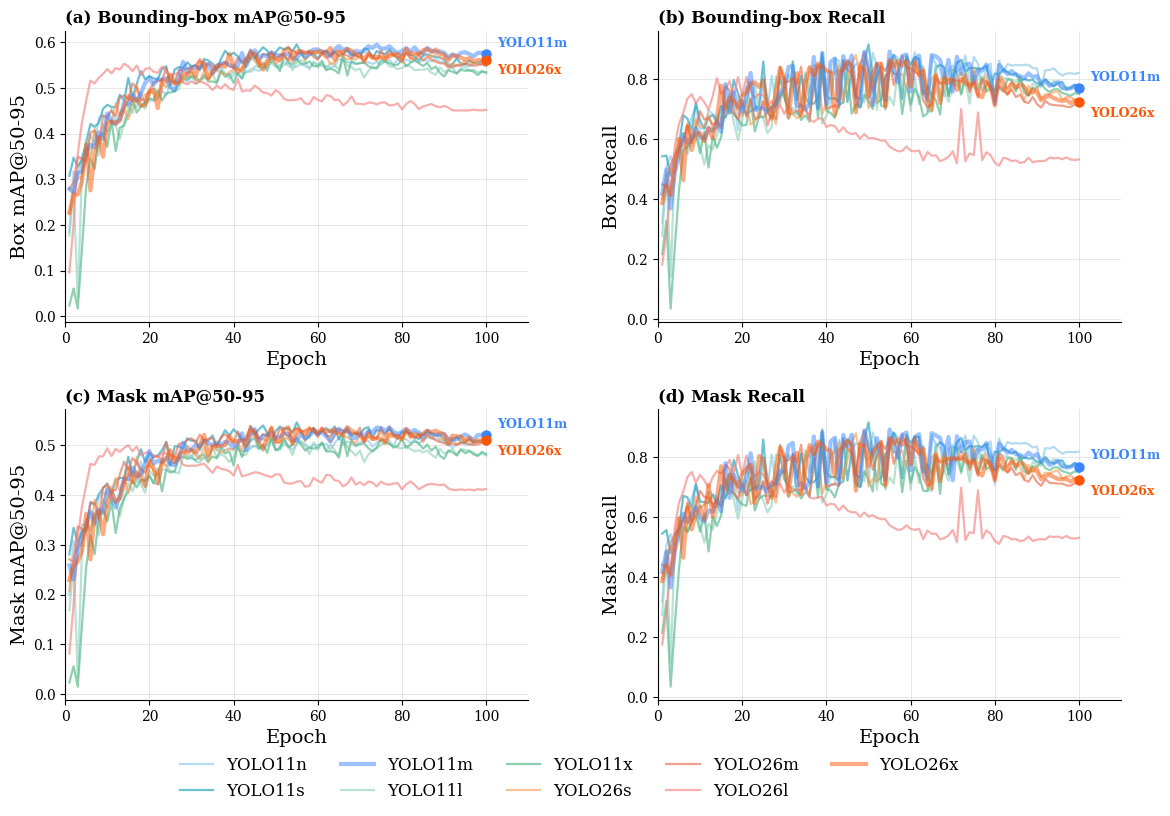

Figura guardada en PNG: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\_comparisons\all_models_curves_highlight_best.png
Figura guardada en PDF: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana\_comparisons\all_models_curves_highlight_best.pdf


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana")
OUT_DIR = BASE_DIR / "_comparisons"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Todos los modelos
RUNS = {
    "YOLO11n": "V11n_640",
    "YOLO11s": "V11s_640",
    "YOLO11m": "V11m_640",
    "YOLO11l": "V11l_640",
    "YOLO11x": "V11x_640",
    "YOLO26s": "V26s_640",
    "YOLO26m": "V26m_640",
    "YOLO26l": "V26l_640",
    "YOLO26x": "V26x_640",
}

# Mejores modelos a destacar
HIGHLIGHT_RUNS = {"YOLO11m", "YOLO26x"}

OUT_PNG = OUT_DIR / "all_models_curves_highlight_best.png"
OUT_PDF = OUT_DIR / "all_models_curves_highlight_best.pdf"

# =========================================================
# ESTILO GLOBAL
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,
    "figure.titlesize": 13,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# COLORES
# =========================================================
# Colores suaves para todos
BASE_COLORS = {
    "YOLO11n": "#8ecae6",
    "YOLO11s": "#219ebc",
    "YOLO11m": "#3a86ff",  # destacado
    "YOLO11l": "#94d2bd",
    "YOLO11x": "#52b788",
    "YOLO26s": "#f4a261",
    "YOLO26m": "#e76f51",
    "YOLO26l": "#f28482",
    "YOLO26x": "#fb5607",  # destacado
}

# offsets distintos para evitar superposición
ANNOT_OFFSETS = {
    "YOLO11m": (8, 8),
    "YOLO26x": (8, -8),
}

# =========================================================
# AUX
# =========================================================
def normalize_columns(df: pd.DataFrame):
    new_cols = {}
    for c in df.columns:
        c2 = c.strip().lower()
        c2 = c2.replace("/", "_").replace("(", "").replace(")", "")
        c2 = c2.replace(" ", "_").replace("-", "_").replace(".", "")
        while "__" in c2:
            c2 = c2.replace("__", "_")
        new_cols[c] = c2
    return df.rename(columns=new_cols)

def load_results(run_dir: Path):
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró {csv_path}")

    df = pd.read_csv(csv_path)
    if df.empty:
        raise ValueError(f"Archivo vacío: {csv_path}")

    df = normalize_columns(df)

    return pd.DataFrame({
        "epoch": df["epoch"],
        "box_map50_95": df["metrics_map50_95b"],
        "mask_map50_95": df["metrics_map50_95m"],
        "box_recall": df["metrics_recallb"],
        "mask_recall": df["metrics_recallm"],
    })

def plot_metric(ax, metric_key, title, ylabel):
    xmax = 0
    for label, run_name in RUNS.items():
        data = load_results(BASE_DIR / run_name)
        xmax = max(xmax, data["epoch"].max())

        is_highlight = label in HIGHLIGHT_RUNS
        color = BASE_COLORS.get(label)

        ax.plot(
            data["epoch"],
            data[metric_key],
            label=label,
            color=color,
            linewidth=3.0 if is_highlight else 1.6,
            alpha=0.5 if is_highlight else 0.65,
            linestyle="-" if "YOLO11" in label else "-",
            zorder=5 if is_highlight else 2,
        )

        if is_highlight:
            x_last = data["epoch"].iloc[-1]
            y_last = data[metric_key].iloc[-1]

            ax.scatter(x_last, y_last, color=color, s=42, zorder=6)

            dx, dy = ANNOT_OFFSETS.get(label, (8, 0))
            ax.annotate(
                label,
                (x_last, y_last),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left",
                va="center",
                fontsize=9,
                color=color,
                fontweight="bold",
                clip_on=False
            )

    # dejar espacio derecho para anotaciones
    ax.set_xlim(0, xmax + 10)

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================================================
# FIGURA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8.8))

plot_metric(axes[0, 0], "box_map50_95", "(a) Bounding-box mAP@50-95", "Box mAP@50-95")
plot_metric(axes[0, 1], "box_recall", "(b) Bounding-box Recall", "Box Recall")
plot_metric(axes[1, 0], "mask_map50_95", "(c) Mask mAP@50-95", "Mask mAP@50-95")
plot_metric(axes[1, 1], "mask_recall", "(d) Mask Recall", "Mask Recall")

# =========================================================
# LEYENDA GLOBAL ABAJO
# =========================================================
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

# fig.suptitle(
#     "Validation curves for all evaluated models with highlighted best-performing configurations",
#     y=0.98
# )

# ajustar espacios manualmente
fig.subplots_adjust(
    left=0.08,
    right=0.96,
    top=0.90,
    bottom=0.14,
    wspace=0.28,
    hspace=0.30
)

# =========================================================
# GUARDAR
# =========================================================
fig.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print(f"Figura guardada en PNG: {OUT_PNG}")
print(f"Figura guardada en PDF: {OUT_PDF}")

### conteo de dataset

In [34]:
from pathlib import Path
import numpy as np
from collections import Counter

# =========================================================
# CONFIGURA TU DATASET
# =========================================================
DATASET_PATH = Path(r"Manzana\yolo_reduced")

LABELS = {
    "train": DATASET_PATH / "labels" / "train",
    "val": DATASET_PATH / "labels" / "val",
}

# Opcional: nombres de clases
CLASS_NAMES = {
      0: "apple_green",
      1: "apple_red",
      2: "peach",
      3: "avocado",
      4: "pear",
      5: "orange"
}

# =========================================================
# FUNCION PRINCIPAL
# =========================================================
def analyze_split(label_dir):
    txt_files = list(label_dir.glob("*.txt"))

    total_images = len(txt_files)
    total_objects = 0
    class_counter = Counter()
    objects_per_image = []
    empty_images = 0

    for txt in txt_files:
        with open(txt, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            empty_images += 1
            objects_per_image.append(0)
            continue

        objects_per_image.append(len(lines))
        total_objects += len(lines)

        for line in lines:
            class_id = int(line.strip().split()[0])
            class_counter[class_id] += 1

    avg_objects = np.mean(objects_per_image) if objects_per_image else 0

    return {
        "total_images": total_images,
        "total_objects": total_objects,
        "avg_objects_per_image": avg_objects,
        "empty_images": empty_images,
        "class_counter": class_counter
    }

# =========================================================
# ANALISIS
# =========================================================
results = {}

for split, path in LABELS.items():
    print(f"\n===== {split.upper()} =====")
    res = analyze_split(path)
    results[split] = res

    print(f"Imágenes: {res['total_images']}")
    print(f"Objetos totales: {res['total_objects']}")
    print(f"Objetos por imagen (avg): {res['avg_objects_per_image']:.2f}")
    print(f"Imágenes vacías: {res['empty_images']}")

    print("\nDistribución por clase:")
    for cls, count in res["class_counter"].items():
        name = CLASS_NAMES.get(cls, f"class_{cls}")
        perc = (count / res["total_objects"]) * 100 if res["total_objects"] > 0 else 0
        print(f"  {name}: {count} ({perc:.2f}%)")

# =========================================================
# COMPARACION TRAIN VS VAL
# =========================================================
print("\n===== COMPARACIÓN =====")

train = results["train"]
val = results["val"]

print(f"Ratio imágenes (train/val): {train['total_images']}/{val['total_images']}")
print(f"Ratio objetos (train/val): {train['total_objects']}/{val['total_objects']}")


===== TRAIN =====
Imágenes: 1224
Objetos totales: 1382
Objetos por imagen (avg): 1.13
Imágenes vacías: 0

Distribución por clase:
  apple_green: 216 (15.63%)
  apple_red: 222 (16.06%)
  peach: 185 (13.39%)
  orange: 211 (15.27%)
  pear: 284 (20.55%)
  avocado: 264 (19.10%)

===== VAL =====
Imágenes: 491
Objetos totales: 584
Objetos por imagen (avg): 1.19
Imágenes vacías: 0

Distribución por clase:
  apple_green: 114 (19.52%)
  apple_red: 99 (16.95%)
  peach: 96 (16.44%)
  orange: 60 (10.27%)
  pear: 93 (15.92%)
  avocado: 122 (20.89%)

===== COMPARACIÓN =====
Ratio imágenes (train/val): 1224/491
Ratio objetos (train/val): 1382/584


In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# =========================================================
# CONFIG
# =========================================================
RUNS_ROOT = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\Manzana")
DATA_YAML = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\data.yaml")
GT_JSON = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Transformer\Manzana\coco_dataset\annotations\instances_val.json")

RUN_NAMES = [
    "V11n_640", 
    "V11s_640", "V11m_640", "V11l_640", "V11x_640",
    "V26n_640", "V26s_640", "V26m_640", "V26l_640", "V26x_640",
]

SPLIT = "val"
CONF = 0.001
IOU = 0.7

OUT_ROOT = RUNS_ROOT / "_iou_curves"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# FUNCIONES
# =========================================================
def find_pred_json(save_dir: Path):
    cands = list(save_dir.rglob("predictions.json")) + list(save_dir.rglob("*.json"))
    for p in cands:
        if p.name == "predictions.json":
            return p
    return cands[0] if cands else None

from pathlib import Path
import json
import os
from pycocotools.coco import COCO

def remap_pred_image_ids_if_needed(gt_json: Path, pred_json: Path):
    gt = COCO(str(gt_json))

    # mapa: nombre de archivo / stem -> id COCO
    name_to_gtid = {}
    for img in gt.dataset["images"]:
        file_name = img["file_name"]          # ej: 20260122_140539_wide.jpg
        stem = Path(file_name).stem           # ej: 20260122_140539_wide
        img_id = int(img["id"])

        name_to_gtid[file_name] = img_id
        name_to_gtid[stem] = img_id
        name_to_gtid[os.path.basename(file_name)] = img_id
        name_to_gtid[Path(os.path.basename(file_name)).stem] = img_id

    with open(pred_json, "r", encoding="utf-8") as f:
        preds = json.load(f)

    # Caso 1: ya son enteros válidos
    all_numeric = True
    pred_ids_numeric = []
    for p in preds:
        try:
            pred_ids_numeric.append(int(p["image_id"]))
        except Exception:
            all_numeric = False
            break

    gt_ids = set(gt.getImgIds())

    if all_numeric:
        pred_ids_numeric = set(pred_ids_numeric)

        # ya coincide
        if pred_ids_numeric.issubset(gt_ids):
            return pred_json

        # caso típico 0..N-1 -> 1..N
        if pred_ids_numeric == set(range(len(gt_ids))):
            out_json = pred_json.with_name(pred_json.stem + "_remap_plus1.json")
            remapped = []
            for p in preds:
                q = p.copy()
                q["image_id"] = int(q["image_id"]) + 1
                remapped.append(q)

            with open(out_json, "w", encoding="utf-8") as f:
                json.dump(remapped, f)

            print(f"[INFO] Remapeado con +1: {out_json}")
            return out_json

    # Caso 2: image_id viene como nombre/string -> mapear por nombre
    remapped = []
    missing = set()

    for p in preds:
        raw_id = str(p["image_id"])

        candidates = [
            raw_id,
            Path(raw_id).name,
            Path(raw_id).stem,
            os.path.basename(raw_id),
            Path(os.path.basename(raw_id)).stem,
        ]

        matched_gtid = None
        for c in candidates:
            if c in name_to_gtid:
                matched_gtid = name_to_gtid[c]
                break

        if matched_gtid is None:
            missing.add(raw_id)
            continue

        q = p.copy()
        q["image_id"] = int(matched_gtid)
        remapped.append(q)

    if missing:
        print("[WARN] Algunos image_id no pudieron mapearse. Ejemplos:")
        for x in list(missing)[:20]:
            print(" -", x)

    out_json = pred_json.with_name(pred_json.stem + "_remap_imageid.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(remapped, f)

    print(f"[INFO] Remapeado por nombre: {out_json}")
    print(f"[INFO] Predicciones originales: {len(preds)} | remapeadas: {len(remapped)}")

    return out_json

def ap_vs_iou(gt_json: Path, pred_json: Path, eval_type: str):
    gt = COCO(str(gt_json))
    pred = gt.loadRes(str(pred_json))

    e = COCOeval(gt, pred, eval_type)
    e.evaluate()
    e.accumulate()
    e.summarize()

    prec = e.eval["precision"]  # [T, R, K, A, M]
    ious = e.params.iouThrs

    prec_mean = np.nanmean(prec, axis=1)
    prec_mean = np.nanmean(prec_mean, axis=(1, 2, 3))

    return pd.DataFrame({
        "iou": ious,
        "ap": prec_mean
    }), e

# =========================================================
# PROCESAR RUNS
# =========================================================
summary_rows = []

for run_name in RUN_NAMES:
    weights = RUNS_ROOT / run_name / "weights" / "best.pt"

    if not weights.exists():
        print(f"[WARN] No existe: {weights}")
        continue

    print(f"\n=== Procesando {run_name} ===")
    model = YOLO(str(weights))

    save_dir = OUT_ROOT / run_name
    save_dir.mkdir(parents=True, exist_ok=True)

    model.val(
        data=str(DATA_YAML),
        split=SPLIT,
        save_json=True,
        conf=CONF,
        iou=IOU,
        plots=False,
        project=str(OUT_ROOT),
        name=run_name,
        exist_ok=True,
        verbose=True
    )

    pred_json = find_pred_json(save_dir)
    if pred_json is None:
        print(f"[WARN] No se encontró JSON de predicciones para {run_name}")
        continue

    print(f"Pred JSON original: {pred_json}")

    pred_json_fixed = remap_pred_image_ids_if_needed(GT_JSON, pred_json)
    print(f"Pred JSON usado: {pred_json_fixed}")    

    df_bbox, bbox_eval = ap_vs_iou(GT_JSON, pred_json_fixed, "bbox")
    df_segm, segm_eval = ap_vs_iou(GT_JSON, pred_json_fixed, "segm")
    
    bbox_csv = save_dir / f"{run_name}_bbox_ap_vs_iou.csv"
    segm_csv = save_dir / f"{run_name}_segm_ap_vs_iou.csv"
    df_bbox.to_csv(bbox_csv, index=False, encoding="utf-8-sig")
    df_segm.to_csv(segm_csv, index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(df_bbox["iou"], df_bbox["ap"], marker="o", linewidth=2.0)
    axes[0].set_title(f"(a) {run_name} Bounding-box AP vs IoU", loc="left", fontweight="bold")
    axes[0].set_xlabel("IoU threshold")
    axes[0].set_ylabel("Average Precision")
    axes[0].set_ylim(0, 1.0)
    axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].plot(df_segm["iou"], df_segm["ap"], marker="o", linewidth=2.0)
    axes[1].set_title(f"(b) {run_name} Mask AP vs IoU", loc="left", fontweight="bold")
    axes[1].set_xlabel("IoU threshold")
    axes[1].set_ylabel("Average Precision")
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.14, wspace=0.28)

    png_path = save_dir / f"{run_name}_ap_vs_iou.png"
    pdf_path = save_dir / f"{run_name}_ap_vs_iou.pdf"
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    summary_rows.append({
        "run": run_name,
        "bbox_mAP_50_95": float(bbox_eval.stats[0]),
        "bbox_mAP_50": float(bbox_eval.stats[1]),
        "segm_mAP_50_95": float(segm_eval.stats[0]),
        "segm_mAP_50": float(segm_eval.stats[1]),
        "pred_json_used": str(pred_json_fixed),
        "bbox_csv": str(bbox_csv),
        "segm_csv": str(segm_csv),
        "png": str(png_path),
        "pdf": str(pdf_path),
    })

df_summary = pd.DataFrame(summary_rows)
summary_csv = OUT_ROOT / "yolo_runs_iou_summary.csv"
df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\nListo.")
print(f"Resumen global: {summary_csv}")
print(df_summary)


=== Procesando V11n_640 ===
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11n-seg summary (fused): 114 layers, 2,835,738 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2537.5591.1 MB/s, size: 629.2 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 377 images, 114 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 491/491  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 7.2it/s 4.3s0.1s
                   all        491        467      0.459      0.886      0.556      0.474      0.459      0.885      0.554      0.436
           apple_green         95         95      0.719          1       0.95      0.903      0.719          1       0.95      0.837
             apple_red   

## Clasificacion por clase

In [14]:
from ultralytics import YOLO
from pathlib import Path
import yaml
import pandas as pd

# =========================================================
# CONFIG
# =========================================================

DATASET_ROOT = Path(r"Manzana/yolo_reduced")
BASE_DATA_YAML = DATASET_ROOT / "data.yaml"

VISIBILITY_LEVELS = ["25%", "50%", "75%", "100%"]

MODELS = {
    "YOLO11m": Path(r"runs/segment/Manzana/V11m_640/weights/best.pt"),
    "YOLO26x": Path(r"runs/segment/Manzana/V26x_640/weights/best.pt"),
}

OUT_DIR = Path(r"validation_by_visibility")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640
BATCH = 8
DEVICE = 0

# =========================================================
# CARGAR DATA.YAML BASE
# =========================================================

with open(BASE_DATA_YAML, "r", encoding="utf-8") as f:
    base_yaml = yaml.safe_load(f)

names = base_yaml["names"]
nc = len(names) if isinstance(names, list) else len(names.keys())

# =========================================================
# CREAR YAML TEMPORAL POR NIVEL DE VISIBILIDAD
# =========================================================

def create_visibility_yaml(level):
    yaml_path = OUT_DIR / f"data_val_visibility_{level.replace('%', 'pct')}.yaml"

    data = {
        "path": str(DATASET_ROOT.resolve()),
        "train": str((DATASET_ROOT / "images/train").resolve()),
        "val": str((DATASET_ROOT / "images/val" / level).resolve()),
        "nc": nc,
        "names": names,
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    return yaml_path

# =========================================================
# VALIDACIÓN
# =========================================================

results_rows = []

for model_name, model_path in MODELS.items():
    print(f"\n==============================")
    print(f"Modelo: {model_name}")
    print(f"Pesos: {model_path}")
    print(f"==============================")

    model = YOLO(str(model_path))

    for level in VISIBILITY_LEVELS:
        print(f"\nValidando {model_name} en visibilidad {level}")

        data_yaml = create_visibility_yaml(level)

        metrics = model.val(
            data=str(data_yaml),
            imgsz=IMG_SIZE,
            batch=BATCH,
            device=DEVICE,
            split="val",
            project=str(OUT_DIR / model_name),
            name=f"val_visibility_{level.replace('%', 'pct')}",
            exist_ok=True,
            verbose=False,
        )

        row = {
            "model": model_name,
            "visibility": level,

            # BBox metrics
            "bbox_precision": metrics.box.mp,
            "bbox_recall": metrics.box.mr,
            "bbox_mAP50": metrics.box.map50,
            "bbox_mAP50_95": metrics.box.map,

            # Mask metrics
            "mask_precision": metrics.seg.mp,
            "mask_recall": metrics.seg.mr,
            "mask_mAP50": metrics.seg.map50,
            "mask_mAP50_95": metrics.seg.map,
        }

        row["bbox_F1"] = (
            2 * row["bbox_precision"] * row["bbox_recall"] /
            (row["bbox_precision"] + row["bbox_recall"] + 1e-9)
        )

        row["mask_F1"] = (
            2 * row["mask_precision"] * row["mask_recall"] /
            (row["mask_precision"] + row["mask_recall"] + 1e-9)
        )

        results_rows.append(row)

# =========================================================
# GUARDAR RESULTADOS
# =========================================================

df_results = pd.DataFrame(results_rows)

csv_path = OUT_DIR / "yolo_visibility_validation_results.csv"
xlsx_path = OUT_DIR / "yolo_visibility_validation_results.xlsx"

df_results.to_csv(csv_path, index=False, encoding="utf-8-sig")
df_results.to_excel(xlsx_path, index=False)

display(df_results)

print("\nResultados guardados en:")
print(csv_path)
print(xlsx_path)


Modelo: YOLO11m
Pesos: runs\segment\Manzana\V11m_640\weights\best.pt

Validando YOLO11m en visibilidad 25%
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 261.5131.3 MB/s, size: 1265.8 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\25%.cache... 142 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 142/142  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 8.3it/s 2.2s0.1s
                   all        142        143      0.583      0.769      0.709      0.561      0.583      0.769      0.709      0.431
Speed: 0.6ms preprocess, 9.8ms inference, 0.0ms loss, 1.1ms postprocess per ima

,model,visibility,bbox_precision,bbox_recall,bbox_mAP50,bbox_mAP50_95,mask_precision,mask_recall,mask_mAP50,mask_mAP50_95,bbox_F1,mask_F1
0,YOLO11m,25%,0.582693,0.768736,0.708956,0.560629,0.582693,0.768736,0.708956,0.431173,0.662909,0.662909
1,YOLO11m,50%,0.670495,0.755044,0.719093,0.623473,0.670495,0.755044,0.719093,0.534953,0.710262,0.710262
2,YOLO11m,75%,0.636596,0.868980,0.750012,0.685234,0.636596,0.868980,0.750012,0.614429,0.734854,0.734854
3,YOLO11m,100%,0.679332,0.865196,0.769190,0.728541,0.679332,0.865196,0.769190,0.688434,0.761080,0.761080
4,YOLO26x,25%,0.695777,0.729526,0.708531,0.515343,0.695777,0.729526,0.708420,0.424903,0.712252,0.712252
5,YOLO26x,50%,0.757339,0.771099,0.750728,0.620757,0.750394,0.761918,0.749478,0.532717,0.764157,0.756112
6,YOLO26x,75%,0.669172,0.889408,0.749668,0.663350,0.669172,0.889408,0.749668,0.610849,0.763730,0.763730
7,YOLO26x,100%,0.760301,0.942310,0.827575,0.758512,0.760301,0.942310,0.827575,0.726832,0.841577,0.841577



Resultados guardados en:
validation_by_visibility\yolo_visibility_validation_results.csv
validation_by_visibility\yolo_visibility_validation_results.xlsx


### crear val.txt para niveles de visibilidad

In [12]:
from pathlib import Path
import shutil

# =========================================================
# CONFIG
# =========================================================

ROOT = Path(r"Manzana/yolo_reduced")

IMG_VAL_DIR = ROOT / "images" / "val"
LBL_VAL_DIR = ROOT / "labels" / "val"

VISIBILITY_LEVELS = ["25%", "50%", "75%", "100%"]

# =========================================================
# CREAR ESTRUCTURA DE LABELS POR VISIBILIDAD
# =========================================================

total_copied = 0
missing_labels = []

for level in VISIBILITY_LEVELS:
    img_dir = IMG_VAL_DIR / level
    lbl_out_dir = LBL_VAL_DIR / level

    lbl_out_dir.mkdir(parents=True, exist_ok=True)

    img_paths = list(img_dir.glob("*"))

    print(f"\nProcesando nivel {level} | imágenes: {len(img_paths)}")

    for img_path in img_paths:
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        label_name = img_path.stem + ".txt"
        src_label = LBL_VAL_DIR / label_name
        dst_label = lbl_out_dir / label_name

        if src_label.exists():
            shutil.copy(src_label, dst_label)
            total_copied += 1
        else:
            missing_labels.append(img_path.name)

print("\n====================================")
print(f"Labels copiados: {total_copied}")
print(f"Labels faltantes: {len(missing_labels)}")

if missing_labels:
    print("\nEjemplos de imágenes sin label:")
    for x in missing_labels[:10]:
        print(" -", x)


Procesando nivel 25% | imágenes: 142

Procesando nivel 50% | imágenes: 94

Procesando nivel 75% | imágenes: 133

Procesando nivel 100% | imágenes: 95

Labels copiados: 463
Labels faltantes: 1

Ejemplos de imágenes sin label:
 - c.png


### por visibilidad Yolo


Modelo: YOLO11m | epochs encontrados: 10
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1528.6343.3 MB/s, size: 609.3 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.9it/s 2.1s0.4s
                   all         95        101      0.449      0.619      0.538       0.42      0.449      0.619       0.54      0.419
Speed: 1.3ms preprocess, 12.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELL

c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarni

                   all         27          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 1.4ms preprocess, 22.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\val6
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2274.2259.2 MB/s, size: 595.6 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95  0.0s
                 Class     Images  Instances      Box(P       

c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarni

                   all         27          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 1.3ms preprocess, 22.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\val11
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2596.4465.6 MB/s, size: 833.6 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95  0.0s
                 Class     Images  Instances      Box(P      

...

                   all         27          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 1.1ms preprocess, 30.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\val91
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO26x-seg summary (fused): 207 layers, 62,733,662 parameters, 0 gradients, 313.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2241.8577.2 MB/s, size: 612.4 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95  0.0s
                 Class     Images  Instances      Box(P      

c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarni

                   all         27          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 0.9ms preprocess, 35.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\val96
Ultralytics 8.4.33  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
YOLO26x-seg summary (fused): 207 layers, 62,733,662 parameters, 0 gradients, 313.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2221.6396.4 MB/s, size: 802.6 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val\100%.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95  0.0s
                 Class     Images  Instances      Box(P      

c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\ProgramData\anaconda3\envs\yolo11\lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\garci\AppData\Roaming\Python\Python310\site-packages\numpy\_core\_methods.py:139: RuntimeWarni

                   all         27          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 1.2ms preprocess, 36.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\runs\segment\val101


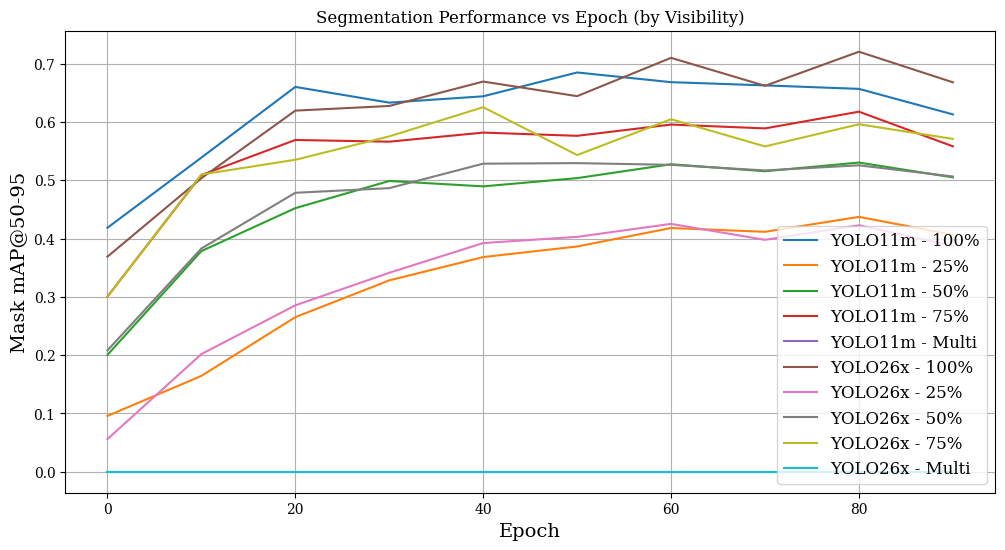

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import re

# =========================================================
# CONFIG
# =========================================================

RUNS = {
    "YOLO11m": Path(r"runs/segment/Manzana/V11m_640/weights"),
    "YOLO26x": Path(r"runs/segment/Manzana/V26x_640/weights"),
}

DATASET_ROOT = Path(r"Manzana/yolo_reduced")
OUT_DIR = Path("epoch_visibility_analysis")
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 640
DEVICE = 0

# detectar visibilidades
VISIBILITY_LEVELS = sorted([
    p.name for p in (DATASET_ROOT / "images/val").iterdir() if p.is_dir()
])

# cargar clases
with open(DATASET_ROOT / "data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]
nc = len(names)

# =========================================================
# YAML TEMPORAL
# =========================================================

def create_yaml(level):
    yaml_path = OUT_DIR / f"val_{level}.yaml"

    data = {
        "path": str(DATASET_ROOT),
        "train": str("images/train"),
        "val": str(f"images/val/{level}"),
        "nc": nc,
        "names": names,
    }

    with open(yaml_path, "w") as f:
        yaml.dump(data, f)

    return yaml_path

# =========================================================
# EXTRAER EPOCH DE NOMBRE
# =========================================================

def get_epoch(weight_path):
    match = re.search(r"epoch(\d+)", weight_path.name)
    return int(match.group(1)) if match else None

# =========================================================
# VALIDACIÓN POR ÉPOCA
# =========================================================

results = []

for model_name, weights_dir in RUNS.items():

    weight_files = sorted(weights_dir.glob("epoch*.pt"))

    print(f"\nModelo: {model_name} | epochs encontrados: {len(weight_files)}")

    for w in weight_files:
        epoch = get_epoch(w)
        if epoch is None:
            continue

        model = YOLO(str(w))

        for level in VISIBILITY_LEVELS:

            yaml_file = create_yaml(level)

            metrics = model.val(
                data=str(yaml_file),
                imgsz=IMG_SIZE,
                device=DEVICE,
                verbose=False
            )

            results.append({
                "model": model_name,
                "epoch": epoch,
                "visibility": level,
                "mask_mAP50_95": metrics.seg.map,
                "mask_recall": metrics.seg.mr,
            })

# =========================================================
# DATAFRAME
# =========================================================

df = pd.DataFrame(results)
df = df.sort_values(["model", "visibility", "epoch"])

df.to_csv(OUT_DIR / "epoch_visibility_results.csv", index=False)

# =========================================================
# GRAFICOS
# =========================================================

plt.figure(figsize=(12, 6))

for (model, vis), sub in df.groupby(["model", "visibility"]):
    plt.plot(
        sub["epoch"],
        sub["mask_mAP50_95"],
        label=f"{model} - {vis}"
    )

plt.xlabel("Epoch")
plt.ylabel("Mask mAP@50-95")
plt.title("Segmentation Performance vs Epoch (by Visibility)")
plt.legend()
plt.grid(True)

plt.savefig(OUT_DIR / "epoch_visibility_map.png", dpi=300)
plt.show()


### Validacion por Visibilidad

Cargando resultados YOLO desde cache: epoch_visibility_analysis\yolo_epoch_visibility_results.csv

CSV guardado en: epoch_visibility_analysis\epoch_visibility_results_with_mask2former.csv


,model,epoch,visibility,mask_mAP50_95,mask_recall
100,Mask2Former,5,100%,0.581,NaN
101,Mask2Former,10,100%,0.640,NaN
102,Mask2Former,15,100%,0.693,NaN
103,Mask2Former,20,100%,0.660,NaN
104,Mask2Former,25,100%,0.738,NaN
...,...,...,...,...,...
79,YOLO26x,50,Multi,0.000,0.0
84,YOLO26x,60,Multi,0.000,0.0
89,YOLO26x,70,Multi,0.000,0.0
94,YOLO26x,80,Multi,0.000,0.0


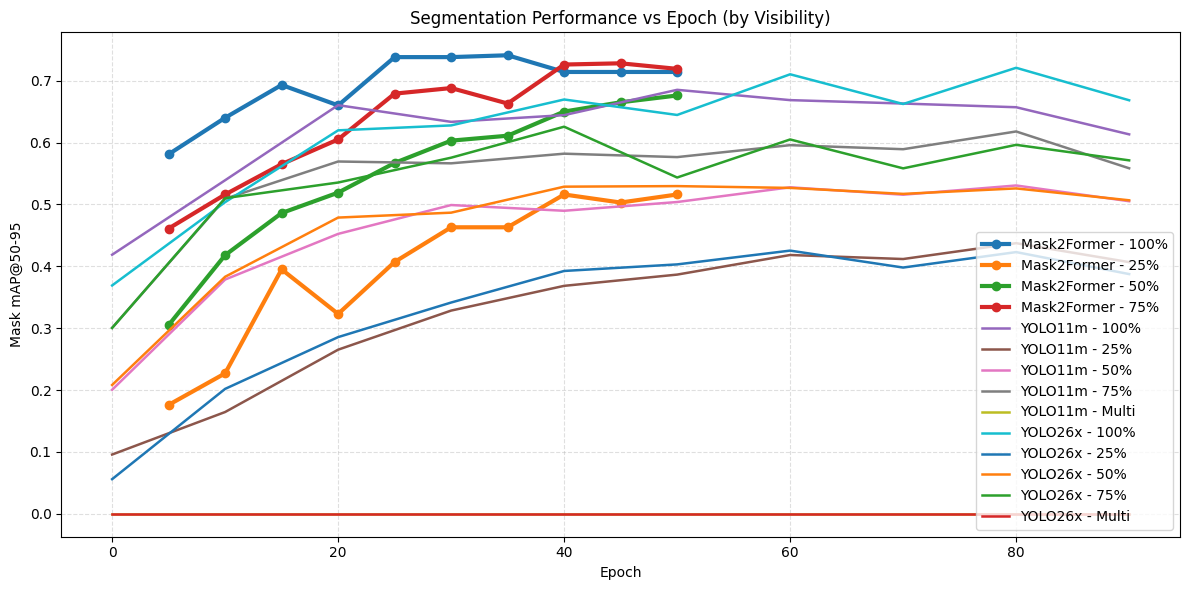

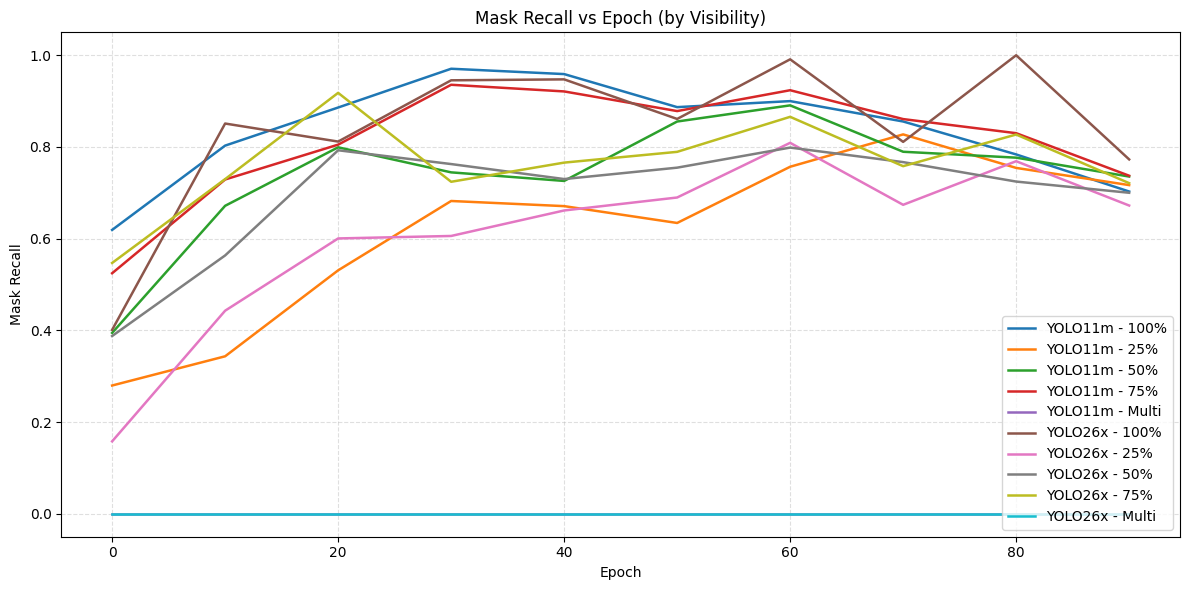

In [5]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import re

# =========================================================
# CONFIG
# =========================================================

RUNS_YOLO = {
    "YOLO11m": Path(r"runs/segment/Manzana/V11m_640/weights"),
    "YOLO26x": Path(r"runs/segment/Manzana/V26x_640/weights"),
}

# CSV generado desde MMDetection con métricas por época y visibilidad
MASK2FORMER_CSV = Path(
    r"C:\workspace\mmdetection\mask2former_visibility_epoch_eval\mask2former_visibility_by_epoch.csv"
)

DATASET_ROOT = Path(r"Manzana/yolo_reduced")
OUT_DIR = Path("epoch_visibility_analysis")
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 640
DEVICE = 0

# Detectar visibilidades
VISIBILITY_LEVELS = sorted([
    p.name for p in (DATASET_ROOT / "images/val").iterdir() if p.is_dir()
])

# Cargar clases
with open(DATASET_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]
nc = len(names)

# =========================================================
# YAML TEMPORAL YOLO
# =========================================================

def safe_name(level):
    return level.replace("%", "pct").replace(" ", "_")

def create_yaml(level):
    yaml_path = OUT_DIR / f"val_{safe_name(level)}.yaml"

    data = {
        "path": str(DATASET_ROOT.resolve()),
        "train": "images/train",
        "val": f"images/val/{level}",
        "nc": nc,
        "names": names,
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    return yaml_path

# =========================================================
# EXTRAER EPOCH YOLO
# =========================================================

def get_epoch(weight_path):
    match = re.search(r"epoch(\d+)", weight_path.name)
    return int(match.group(1)) if match else None

# =========================================================
# VALIDACIÓN YOLO POR ÉPOCA
# =========================================================
YOLO_CACHE = OUT_DIR / "yolo_epoch_visibility_results.csv"

if YOLO_CACHE.exists():
    print(f"Cargando resultados YOLO desde cache: {YOLO_CACHE}")
    df_yolo_cache = pd.read_csv(YOLO_CACHE)
    results = df_yolo_cache.to_dict("records")
else:
    # results = []
    # aquí va tu loop de validación YOLO
    results = []

    for model_name, weights_dir in RUNS_YOLO.items():

        weight_files = sorted(
            weights_dir.glob("epoch*.pt"),
            key=lambda p: get_epoch(p) if get_epoch(p) is not None else 999999
        )

        print(f"\nModelo: {model_name} | epochs encontrados: {len(weight_files)}")

        for w in weight_files:
            epoch = get_epoch(w)
            if epoch is None:
                continue

            model = YOLO(str(w))

            for level in VISIBILITY_LEVELS:
                yaml_file = create_yaml(level)

                print(f"Validando {model_name} | epoch {epoch} | vis {level}")

                metrics = model.val(
                    data=str(yaml_file),
                    imgsz=IMG_SIZE,
                    device=DEVICE,
                    verbose=False
                )

                results.append({
                    "model": model_name,
                    "epoch": epoch,
                    "visibility": level,
                    "mask_mAP50_95": metrics.seg.map,
                    "mask_recall": metrics.seg.mr,
                })
                pd.DataFrame(results).to_csv(YOLO_CACHE, index=False, encoding="utf-8-sig")

# =========================================================
# AGREGAR MASK2FORMER DESDE CSV
# =========================================================

if MASK2FORMER_CSV.exists():
    df_m2f = pd.read_csv(MASK2FORMER_CSV)

    rename_map = {
        "segm_mAP50_95": "mask_mAP50_95",
        "metrics/mAP50-95(M)": "mask_mAP50_95",
        "metrics/recall(M)": "mask_recall",
        "segm_recall": "mask_recall",
    }

    df_m2f = df_m2f.rename(columns=rename_map)

    if "model" not in df_m2f.columns:
        df_m2f["model"] = "Mask2Former"

    if "visibility" not in df_m2f.columns:
        df_m2f["visibility"] = "Multi"

    df_m2f["visibility"] = df_m2f["visibility"].astype(str)
    df_m2f["visibility"] = df_m2f["visibility"].apply(
        lambda x: x if x.endswith("%") or x == "Multi" else x + "%"
    )

    if "mask_recall" not in df_m2f.columns:
        df_m2f["mask_recall"] = None

    df_m2f = df_m2f[[
        "model",
        "epoch",
        "visibility",
        "mask_mAP50_95",
        "mask_recall"
    ]]

    results = [r for r in results if r.get("model") != "Mask2Former"]
    results.extend(df_m2f.to_dict("records"))

else:
    print(f"⚠️ No se encontró CSV de Mask2Former: {MASK2FORMER_CSV}")


# =========================================================
# DATAFRAME FINAL
# =========================================================

df = pd.DataFrame(results)

df["visibility"] = df["visibility"].astype(str)
df = df.sort_values(["model", "visibility", "epoch"])

csv_out = OUT_DIR / "epoch_visibility_results_with_mask2former.csv"
df.to_csv(csv_out, index=False, encoding="utf-8-sig")

print(f"\nCSV guardado en: {csv_out}")
display(df)

# =========================================================
# GRÁFICO 1: MASK mAP@50-95
# =========================================================

plt.figure(figsize=(12, 6))

for (model, vis), sub in df.groupby(["model", "visibility"]):
    sub = sub.sort_values("epoch")

    plt.plot(
        sub["epoch"],
        sub["mask_mAP50_95"],
        marker="o" if model == "Mask2Former" else None,
        linewidth=3.0 if model == "Mask2Former" else 1.8,
        label=f"{model} - {vis}"
    )

plt.xlabel("Epoch")
plt.ylabel("Mask mAP@50-95")
plt.title("Segmentation Performance vs Epoch (by Visibility)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(OUT_DIR / "epoch_visibility_map_with_mask2former.png", dpi=600)
plt.savefig(OUT_DIR / "epoch_visibility_map_with_mask2former.pdf")
plt.show()

# =========================================================
# GRÁFICO 2: MASK RECALL
# =========================================================

df_recall = df.dropna(subset=["mask_recall"])

if not df_recall.empty:
    plt.figure(figsize=(12, 6))

    for (model, vis), sub in df_recall.groupby(["model", "visibility"]):
        sub = sub.sort_values("epoch")

        plt.plot(
            sub["epoch"],
            sub["mask_recall"],
            marker="o" if model == "Mask2Former" else None,
            linewidth=3.0 if model == "Mask2Former" else 1.8,
            label=f"{model} - {vis}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Mask Recall")
    plt.title("Mask Recall vs Epoch (by Visibility)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    plt.savefig(OUT_DIR / "epoch_visibility_recall_with_mask2former.png", dpi=600)
    plt.savefig(OUT_DIR / "epoch_visibility_recall_with_mask2former.pdf")
    plt.show()

## v2

Cargando resultados YOLO desde cache: epoch_visibility_analysis\yolo_epoch_visibility_results.csv

CSV guardado en: epoch_visibility_analysis\epoch_visibility_results_with_mask2former.csv


,model,epoch,visibility,mask_mAP50_95,mask_recall
100,Mask2Former,5,100%,0.581000,NaN
101,Mask2Former,10,100%,0.640000,NaN
102,Mask2Former,15,100%,0.693000,NaN
103,Mask2Former,20,100%,0.660000,NaN
104,Mask2Former,25,100%,0.738000,NaN
...,...,...,...,...,...
78,YOLO26x,50,75%,0.543440,0.789352
83,YOLO26x,60,75%,0.604928,0.865741
88,YOLO26x,70,75%,0.558240,0.758102
93,YOLO26x,80,75%,0.596236,0.827152


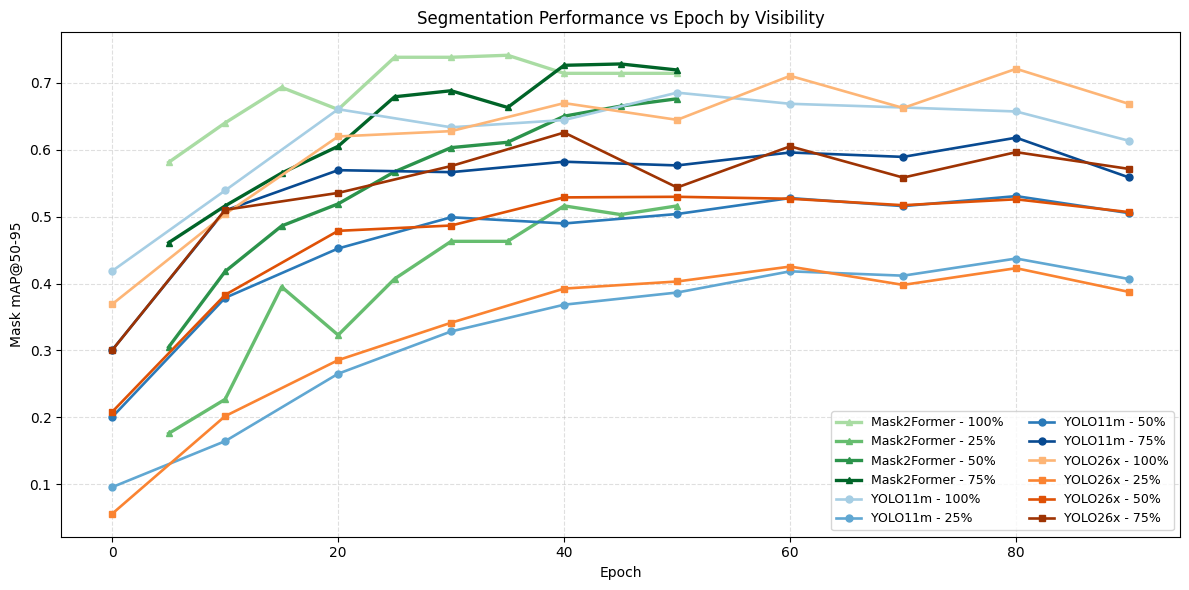

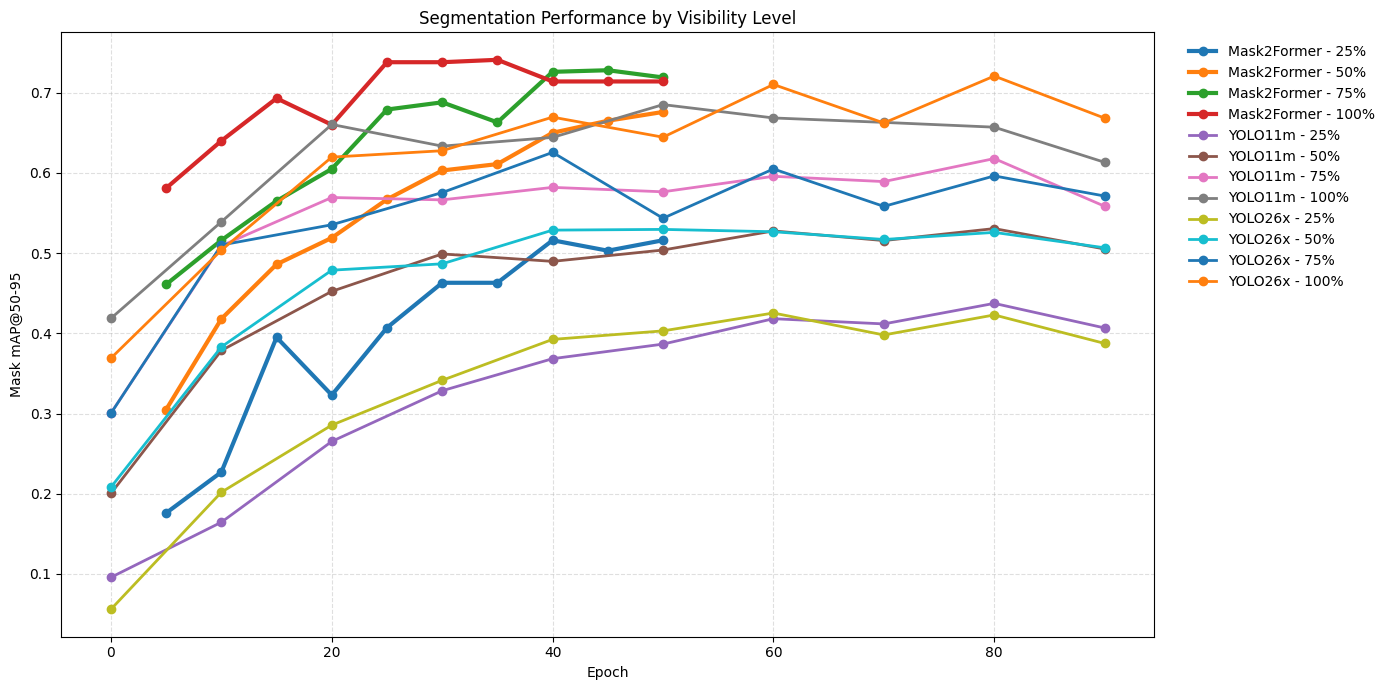

Guardado en:
epoch_visibility_analysis\mask_visibility_comparison.png
epoch_visibility_analysis\mask_visibility_comparison.pdf


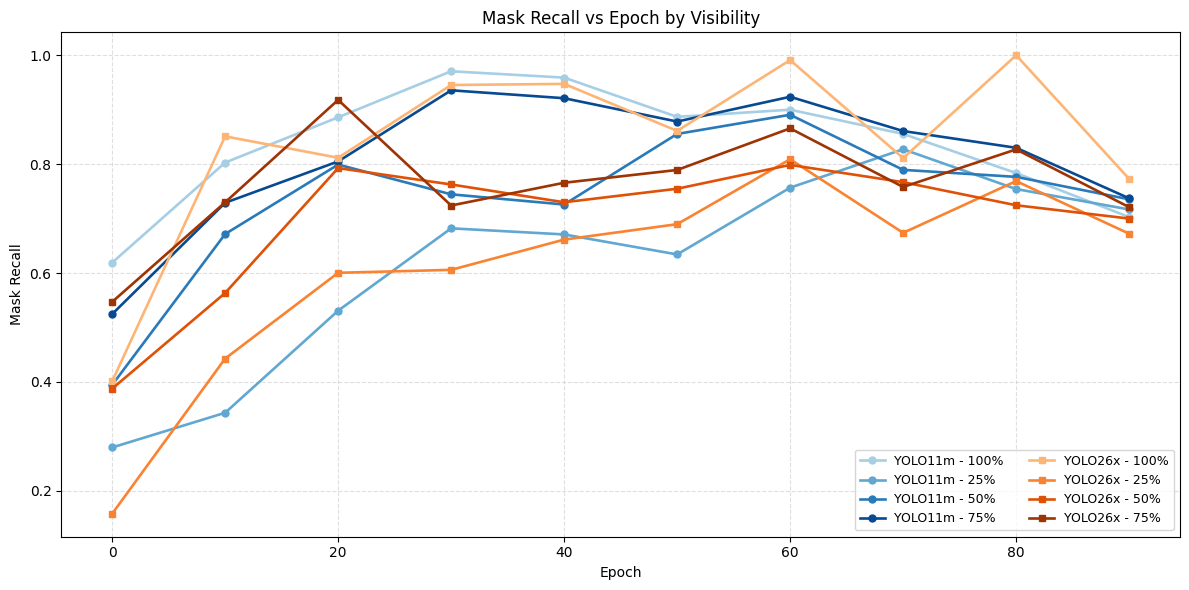

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import re

# =========================================================
# CONFIG
# =========================================================

RUNS_YOLO = {
    "YOLO11m": Path(r"runs/segment/Manzana/V11m_640/weights"),
    "YOLO26x": Path(r"runs/segment/Manzana/V26x_640/weights"),
}

# CSV generado desde MMDetection con métricas por época y visibilidad
MASK2FORMER_CSV = Path(
    r"C:\workspace\mmdetection\mask2former_visibility_epoch_eval\mask2former_visibility_by_epoch.csv"
)

DATASET_ROOT = Path(r"Manzana/yolo_reduced")
OUT_DIR = Path("epoch_visibility_analysis")
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 640
DEVICE = 0

# Detectar visibilidades
VISIBILITY_LEVELS = sorted([
    p.name for p in (DATASET_ROOT / "images/val").iterdir() if p.is_dir()
])

# Cargar clases
with open(DATASET_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]
nc = len(names)

# =========================================================
# YAML TEMPORAL YOLO
# =========================================================

def safe_name(level):
    return level.replace("%", "pct").replace(" ", "_")

def create_yaml(level):
    yaml_path = OUT_DIR / f"val_{safe_name(level)}.yaml"

    data = {
        "path": str(DATASET_ROOT.resolve()),
        "train": "images/train",
        "val": f"images/val/{level}",
        "nc": nc,
        "names": names,
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    return yaml_path

# =========================================================
# EXTRAER EPOCH YOLO
# =========================================================

def get_epoch(weight_path):
    match = re.search(r"epoch(\d+)", weight_path.name)
    return int(match.group(1)) if match else None

# =========================================================
# VALIDACIÓN YOLO POR ÉPOCA
# =========================================================
YOLO_CACHE = OUT_DIR / "yolo_epoch_visibility_results.csv"

if YOLO_CACHE.exists():
    print(f"Cargando resultados YOLO desde cache: {YOLO_CACHE}")
    df_yolo_cache = pd.read_csv(YOLO_CACHE)
    results = df_yolo_cache.to_dict("records")
else:
    # results = []
    # aquí va tu loop de validación YOLO
    results = []

    for model_name, weights_dir in RUNS_YOLO.items():

        weight_files = sorted(
            weights_dir.glob("epoch*.pt"),
            key=lambda p: get_epoch(p) if get_epoch(p) is not None else 999999
        )

        print(f"\nModelo: {model_name} | epochs encontrados: {len(weight_files)}")

        for w in weight_files:
            epoch = get_epoch(w)
            if epoch is None:
                continue

            model = YOLO(str(w))

            for level in VISIBILITY_LEVELS:
                yaml_file = create_yaml(level)

                print(f"Validando {model_name} | epoch {epoch} | vis {level}")

                metrics = model.val(
                    data=str(yaml_file),
                    imgsz=IMG_SIZE,
                    device=DEVICE,
                    verbose=False
                )

                results.append({
                    "model": model_name,
                    "epoch": epoch,
                    "visibility": level,
                    "mask_mAP50_95": metrics.seg.map,
                    "mask_recall": metrics.seg.mr,
                })
                pd.DataFrame(results).to_csv(YOLO_CACHE, index=False, encoding="utf-8-sig")

# =========================================================
# AGREGAR MASK2FORMER DESDE CSV
# =========================================================

if MASK2FORMER_CSV.exists():
    df_m2f = pd.read_csv(MASK2FORMER_CSV)

    rename_map = {
        "segm_mAP50_95": "mask_mAP50_95",
        "metrics/mAP50-95(M)": "mask_mAP50_95",
        "metrics/recall(M)": "mask_recall",
        "segm_recall": "mask_recall",
    }

    df_m2f = df_m2f.rename(columns=rename_map)

    if "model" not in df_m2f.columns:
        df_m2f["model"] = "Mask2Former"

    # -----------------------------------------------------
    # Quitar variable Multi
    # -----------------------------------------------------
    if "visibility" not in df_m2f.columns:
        raise ValueError(
            "El CSV de Mask2Former no contiene la columna 'visibility'. "
            "Para comparar por visibilidad, el CSV debe incluir niveles como 25%, 50%, 75% y 100%."
        )

    df_m2f["visibility"] = df_m2f["visibility"].astype(str)

    # Normalizar nombres de visibilidad
    df_m2f["visibility"] = df_m2f["visibility"].apply(
        lambda x: x if x.endswith("%") else x + "%"
    )

    # Eliminar filas Multi si existieran en el CSV
    df_m2f = df_m2f[df_m2f["visibility"].str.lower() != "multi"]

    if "mask_recall" not in df_m2f.columns:
        df_m2f["mask_recall"] = None

    df_m2f = df_m2f[[
        "model",
        "epoch",
        "visibility",
        "mask_mAP50_95",
        "mask_recall"
    ]]

    results = [r for r in results if r.get("model") != "Mask2Former"]
    results.extend(df_m2f.to_dict("records"))

else:
    print(f"⚠️ No se encontró CSV de Mask2Former: {MASK2FORMER_CSV}")


# =========================================================
# DATAFRAME FINAL
# =========================================================

df = pd.DataFrame(results)

df["visibility"] = df["visibility"].astype(str)

# Eliminar cualquier fila Multi que pueda venir del cache u otra fuente
df = df[df["visibility"].str.lower() != "multi"]

df = df.sort_values(["model", "visibility", "epoch"])

csv_out = OUT_DIR / "epoch_visibility_results_with_mask2former.csv"
df.to_csv(csv_out, index=False, encoding="utf-8-sig")

print(f"\nCSV guardado en: {csv_out}")
display(df)


# =========================================================
# PALETAS DE COLOR POR ARQUITECTURA
# =========================================================

def get_architecture(model_name):
    model_name_lower = model_name.lower()

    if "yolo11" in model_name_lower:
        return "YOLO11"
    elif "yolo26" in model_name_lower:
        return "YOLO26"
    elif "mask2former" in model_name_lower:
        return "Mask2Former"
    else:
        return "Other"


ARCH_PALETTES = {
    "YOLO11": plt.cm.Blues,
    "YOLO26": plt.cm.Oranges,
    "Mask2Former": plt.cm.Greens,
    "Other": plt.cm.Greys,
}

ARCH_LINESTYLES = {
    "YOLO11": "-",
    "YOLO26": "-",
    "Mask2Former": "-",#"--",
    "Other": "-.",
}

ARCH_MARKERS = {
    "YOLO11": "o",
    "YOLO26": "s",
    "Mask2Former": "^",
    "Other": "x",
}


def build_color_map(df_plot):
    """
    Asigna colores según arquitectura y nivel de visibilidad.
    Cada arquitectura usa una paleta distinta.
    """

    color_map = {}

    for arch, sub_arch in df_plot.assign(
        architecture=df_plot["model"].apply(get_architecture)
    ).groupby("architecture"):

        vis_levels = sorted(sub_arch["visibility"].unique())

        cmap = ARCH_PALETTES.get(arch, plt.cm.Greys)

        # Se evita usar colores demasiado claros de la paleta
        color_values = [
            cmap(x) for x in
            [0.35 + 0.55 * i / max(len(vis_levels) - 1, 1) for i in range(len(vis_levels))]
        ]

        for vis, color in zip(vis_levels, color_values):
            color_map[(arch, vis)] = color

    return color_map


# =========================================================
# GRÁFICO 1: MASK mAP@50-95
# =========================================================

plt.figure(figsize=(12, 6))

color_map = build_color_map(df)

for (model, vis), sub in df.groupby(["model", "visibility"]):
    sub = sub.sort_values("epoch")

    arch = get_architecture(model)

    plt.plot(
        sub["epoch"],
        sub["mask_mAP50_95"],
        color=color_map[(arch, vis)],
        linestyle=ARCH_LINESTYLES.get(arch, "-"),
        marker=ARCH_MARKERS.get(arch, "o"),
        markersize=5,
        linewidth=2.4 if arch == "Mask2Former" else 1.9,
        label=f"{model} - {vis}"
    )

plt.xlabel("Epoch")
plt.ylabel("Mask mAP@50-95")
plt.title("Segmentation Performance vs Epoch by Visibility")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(OUT_DIR / "epoch_visibility_map_with_mask2former.png", dpi=600)
plt.savefig(OUT_DIR / "epoch_visibility_map_with_mask2former.pdf")
plt.show()


# =========================================================
# GRÁFICO 2: MASK RECALL
# =========================================================

df_recall = df.dropna(subset=["mask_recall"])

if not df_recall.empty:
    plt.figure(figsize=(12, 6))

    color_map = build_color_map(df_recall)

    for (model, vis), sub in df_recall.groupby(["model", "visibility"]):
        sub = sub.sort_values("epoch")

        arch = get_architecture(model)

        plt.plot(
            sub["epoch"],
            sub["mask_recall"],
            color=color_map[(arch, vis)],
            linestyle=ARCH_LINESTYLES.get(arch, "-"),
            marker=ARCH_MARKERS.get(arch, "o"),
            markersize=5,
            linewidth=2.4 if arch == "Mask2Former" else 1.9,
            label=f"{model} - {vis}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Mask Recall")
    plt.title("Mask Recall vs Epoch by Visibility")
    plt.legend(ncol=2, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    plt.savefig(OUT_DIR / "epoch_visibility_recall_with_mask2former.png", dpi=600)
    plt.savefig(OUT_DIR / "epoch_visibility_recall_with_mask2former.pdf")
    plt.show()

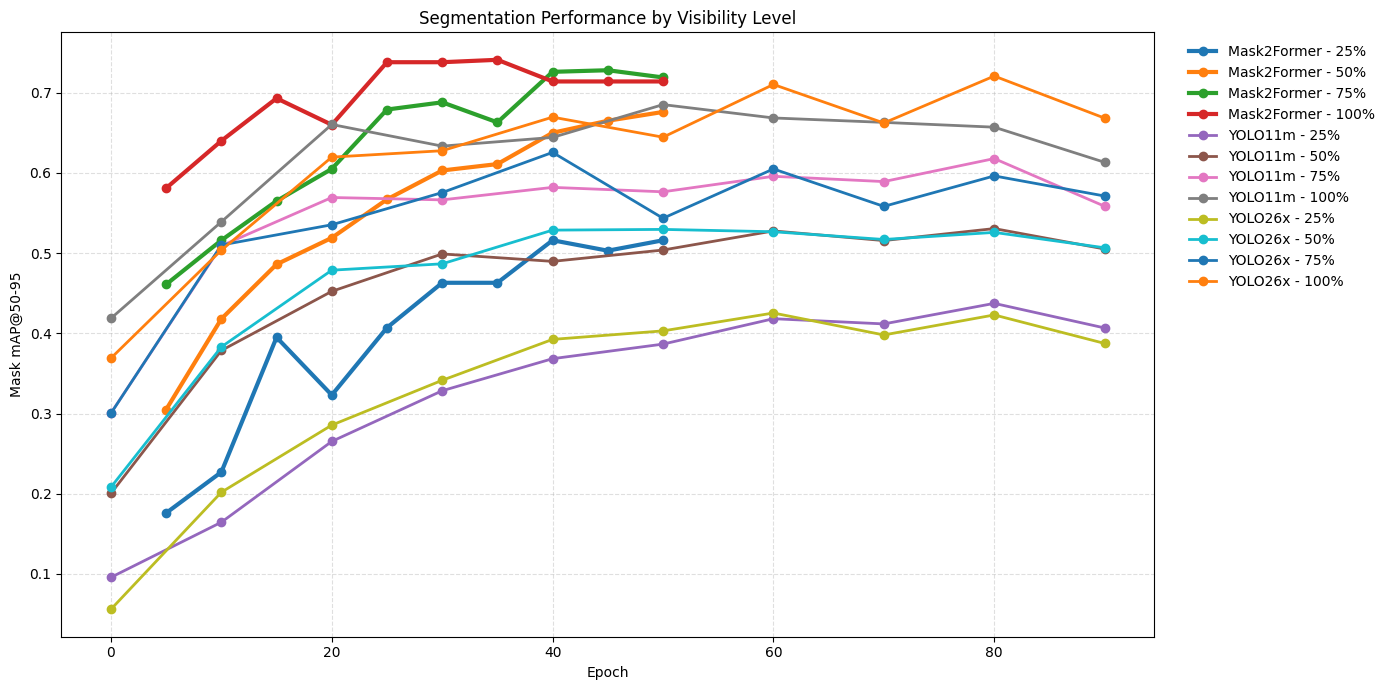

Guardado en:
epoch_visibility_analysis\mask_visibility_comparison.png
epoch_visibility_analysis\mask_visibility_comparison.pdf


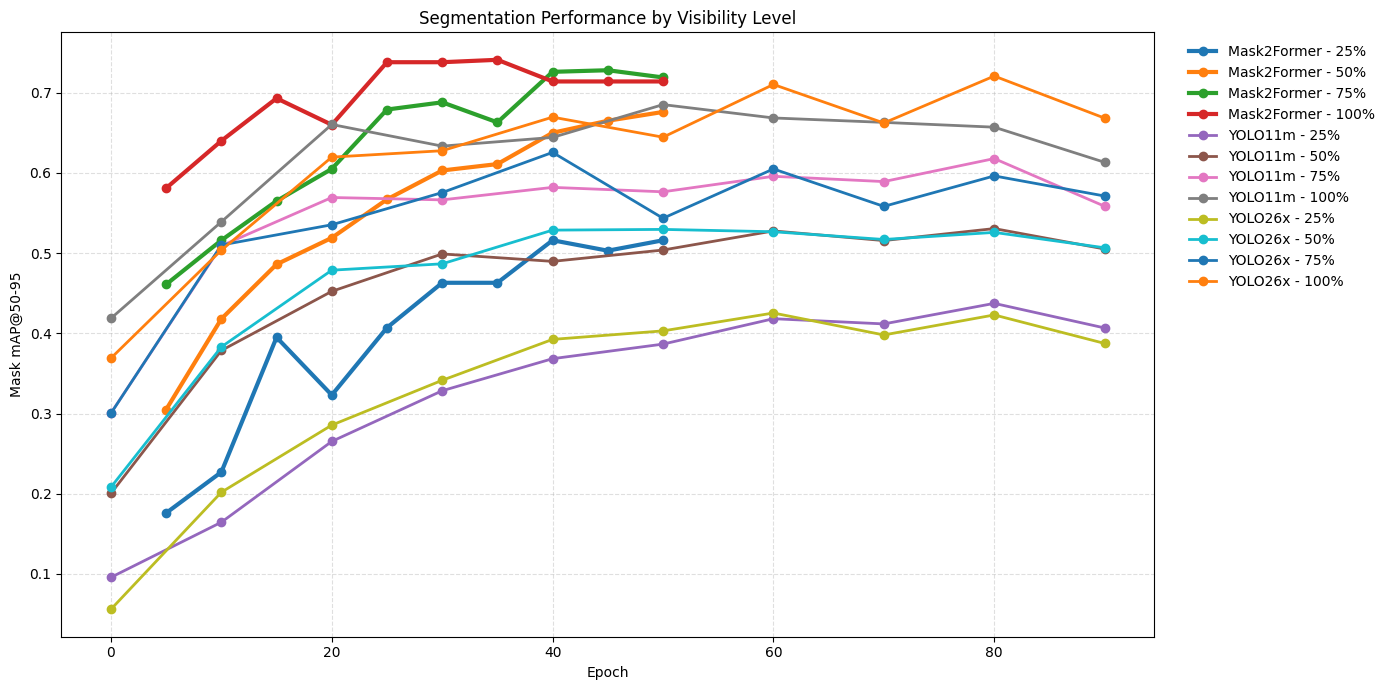

In [11]:
import matplotlib.pyplot as plt
from IPython.display import display

fig, ax = plt.subplots(figsize=(14, 7))

for (model, vis), sub in df_plot.groupby(["model", "visibility"], observed=True):
    sub = sub.sort_values("epoch")

    ax.plot(
        sub["epoch"],
        sub["mask_mAP50_95"],
        marker="o",
        linewidth=3 if model == "Mask2Former" else 2,
        label=f"{model} - {vis}"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Segmentation Performance by Visibility Level")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

fig.tight_layout()

png_path = OUT_DIR / "mask_visibility_comparison.png"
pdf_path = OUT_DIR / "mask_visibility_comparison.pdf"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

display(fig)

print("Guardado en:")
print(png_path)
print(pdf_path)